# Unbinned Image Deconvolution Tutorial with cosipy

This tutorial demonstrates how to implement unbinned image deconvolution using cosipy.

Key steps in this tutorial:
1. Generate a true image and simulate detector response for each event under simplified 2D response
2. Create probability maps for each event
3. Implement custom Model and DataInterface classes
4. Run image deconvolution using Richardson-Lucy algorithm
5. Visualize and evaluate results

Note that the background is ignored on this notebook, while the background treatment is a challenging topic in the unbinned analysis.

In [1]:
import logging
import sys
logger = logging.getLogger('cosipy')
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(sys.stdout))

In [2]:
from histpy import Histogram, Axes, Axis
import numpy as np
from tqdm.notebook import trange, tqdm
import pandas as pd
import matplotlib.pyplot as plt
import astropy.io.fits as fits

# 1. True Image

First, we create a true image that will be the source of our simulated events.
For this tutorial, we use a simple scenario with two point sources:
- A strong source (intensity=10) at the center
- A weaker source (intensity=5) offset from center

You can also change the true image by commeting out the folling cell. The image resolution is assumed to be 64x64.

In [3]:
nx, ny = 64, 64

In [4]:
axes = Axes([np.linspace(0, nx, nx+1), np.linspace(0, ny, ny+1)], labels = ['x', 'y'])
true_image = Histogram(axes, track_overflow = False)

In [5]:
# a single point source at the center
#true_image[32,32] = 10

# two point sources
true_image[32,32] = 10
true_image[16,24] = 5

# a ring
#for ix in range(nx):
#    for iy in range(ny):
#        true_image[ix,iy] = 1 if (10 < ((ix-nx/2)**2 + (iy-ny/2)**2)**0.5 < 12) else 0

(<Axes: xlabel='x', ylabel='y'>,
 <matplotlib.collections.QuadMesh at 0x16c317d00>)

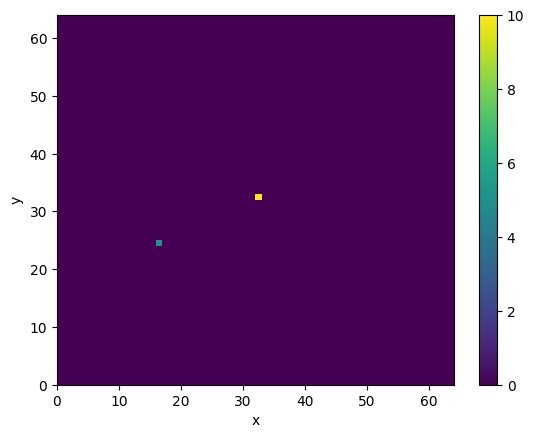

In [6]:
# Visualize true image
true_image.draw()

# 2. Make Event List

This chapter simulates detected events from our true image. For unbinned analysis, 
each event has:
1. A true source position (sampled from the true image)
2. A detection uncertainty (varying by event)
3. A measured position (sampled using the uncertainty)

In this simulation, we assume:
- Position resolution varies event by event
- Measured positions have Gaussian uncertainties

In [7]:
# sample the source position for each event

def sample_source_position(true_image):
    """
    Sample a source position based on the true image intensity distribution.
    
    Args:
        true_image (Histogram): The true source distribution
        
    Returns:
        numpy.ndarray: Sampled (x,y) position
    """
    array_2d = true_image[:]
    
    flat_weights = array_2d.ravel()
    probs = flat_weights / flat_weights.sum()
    
    flat_idx = np.random.choice(len(flat_weights), p=probs)
    
    rows, cols = array_2d.shape
    row_idx = flat_idx // cols
    col_idx = flat_idx % cols
    
    return np.array([true_image.axes[0].centers[row_idx], true_image.axes[1].centers[col_idx]])

In [8]:
# sample the detection error (1 sigma)

def sample_detection_error(sigma_low = 5, sigma_high = 20):
    """
    Sample a detection uncertainty (1 sigma) uniformly between bounds.
    
    Args:
        sigma_low (float): Minimum uncertainty
        sigma_high (float): Maximum uncertainty
        
    Returns:
        float: Sampled uncertainty value
    """
    return np.random.uniform(sigma_low, sigma_high)

In [9]:
# sample the detected position

def sample_detected_position(source_position, sigma):
    """
    Sample a measured position given true position and uncertainty.
    
    Args:
        source_position (numpy.ndarray): True (x,y) position
        sigma (float): Detection uncertainty
        
    Returns:
        numpy.ndarray: Sampled measured (x,y) position
    """
    return np.random.multivariate_normal(source_position, cov = [[sigma**2, 0],[0, sigma**2]])

In [10]:
# Generate event sample

n_sample = 10000  # Number of events to simulate
sigma_low, sigma_high = 5, 10  # Range of position uncertainties

# Create event list with detected positions and uncertainties
event_list = []

for event_id in trange(n_sample):

    source_position = sample_source_position(true_image)

    error_sigma = sample_detection_error(sigma_low, sigma_high)

    detected_position = sample_detected_position(source_position, error_sigma)

    event_list.append([event_id, detected_position[0], detected_position[1], error_sigma])
    
event_list = pd.DataFrame(event_list, columns=['eventid', 'x_detected', 'y_detected', 'error'])
event_list

  0%|          | 0/10000 [00:00<?, ?it/s]

,eventid,x_detected,y_detected,error
0,0,52.924898,24.854475,9.415965
1,1,34.983903,26.707316,6.227742
2,2,27.661502,34.373134,6.702017
3,3,10.634474,21.449184,7.143377
4,4,-0.942841,9.487264,9.249652
...,...,...,...,...
9995,9995,14.105296,14.245494,7.854526
9996,9996,34.510859,19.799749,6.393875
9997,9997,28.774516,29.607515,8.450249
9998,9998,20.405004,33.268190,6.609746


In [11]:
# Convert to DataFrame and save
event_list.to_csv('event_list.csv', index = False)

In [12]:
event_list = pd.read_csv('event_list.csv')
event_list

,eventid,x_detected,y_detected,error
0,0,52.924898,24.854475,9.415965
1,1,34.983903,26.707316,6.227742
2,2,27.661502,34.373134,6.702017
3,3,10.634474,21.449184,7.143377
4,4,-0.942841,9.487264,9.249652
...,...,...,...,...
9995,9995,14.105296,14.245494,7.854526
9996,9996,34.510859,19.799749,6.393875
9997,9997,28.774516,29.607515,8.450249
9998,9998,20.405004,33.268190,6.609746


## (Check the detected position distribution)

  0%|          | 0/10000 [00:00<?, ?it/s]

(<Axes: xlabel='x', ylabel='y'>,
 <matplotlib.collections.QuadMesh at 0x16c558700>)

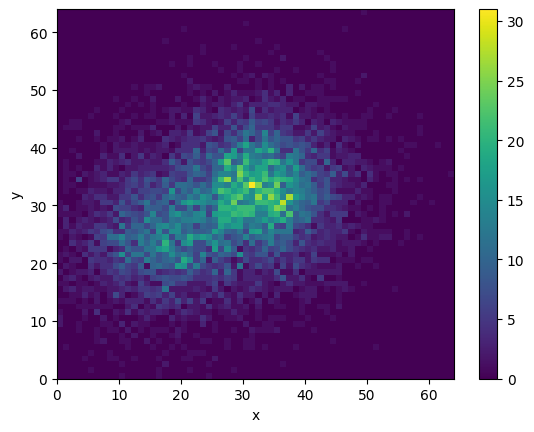

In [13]:
# Quick visualization of detected events

axes = Axes([np.linspace(0, nx, nx+1), np.linspace(0, ny, ny+1)], labels = ['x', 'y'])
filled_event_distribution = Histogram(axes)

for data in tqdm(event_list.itertuples(), total = len(event_list)):
    filled_event_distribution.fill(np.array([data.x_detected, data.y_detected]))

filled_event_distribution.draw()

# 3. Generate a probability map for each event

For unbinned image deconvolution, we need to calculate the probability distribution
for each event's true position given its measured position and uncertainty.

In this implementation:
- Each event gets its own 2D probability map
- Maps are calculated using 2D Gaussian distributions
- All maps are stored in a 3D histogram (eventid, x, y)

These probability maps form the response matrix for our deconvolution problem,
connecting the true image space to our measurements.

In [14]:
def generate_probability_map(detected_position, error):
    """
    Generate a 2D probability map for a single event.
    
    Args:
        detected_position (numpy.ndarray): Measured (x,y) position
        error (float): Detection uncertainty (sigma)
    
    Returns:
        Histogram: Normalized probability map
    """
    # Create axes matching the image space
    axes = Axes([np.linspace(0, nx, nx+1), np.linspace(0, ny, ny+1)], labels = ['x', 'y'])
    probability_map = Histogram(axes, track_overflow = False)

    # Calculate Gaussian weights for x and y dimensions
    weight_x = np.exp(-0.5 * (probability_map.axes['x'].centers - detected_position[0])**2 / error**2)
    weight_y = np.exp(-0.5 * (probability_map.axes['y'].centers - detected_position[1])**2 / error**2)

    # Create 2D probability distribution and normalize
    probability_map[:] = np.outer(weight_x, weight_y)
    probability_map[:] /= np.sum(probability_map)

    return probability_map

In [15]:
# Generate and store probability maps for all events

num_event = len(event_list)

axes = Axes([np.linspace(0, num_event, num_event+1), np.linspace(0, nx, nx+1), np.linspace(0, ny, ny+1)], labels = ['eventid', 'x', 'y'])
probability_map_list = Histogram(axes, track_overflow = False)

# Fill probability maps
for i, data in tqdm(enumerate(event_list.itertuples()), total = len(event_list)):
    probability_map = generate_probability_map(np.array([data.x_detected, data.y_detected]), data.error)
    probability_map_list[i] = probability_map[:]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [16]:
# Save probability maps
probability_map_list.write('probability_map_list.hdf5', overwrite=True)

In [17]:
probability_map_list = Histogram.open('probability_map_list.hdf5')

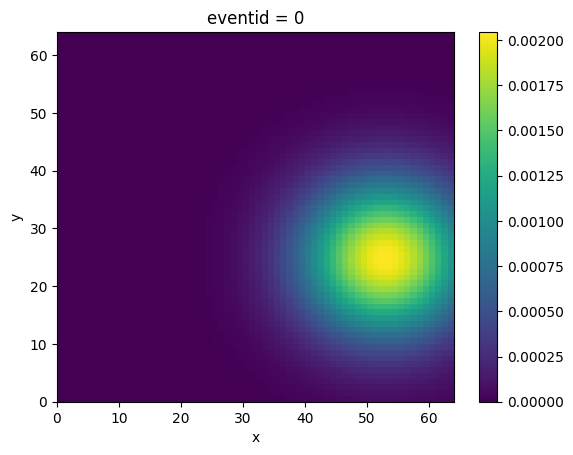

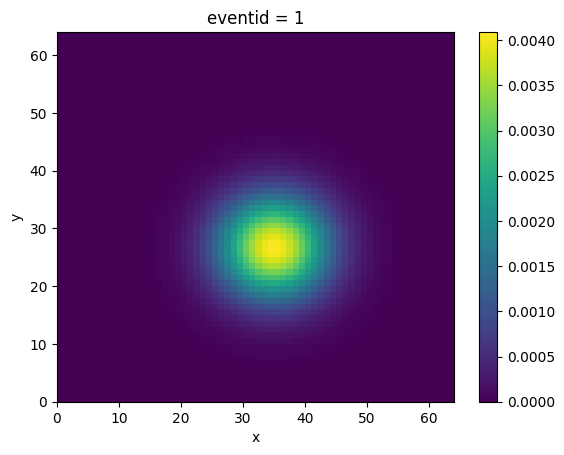

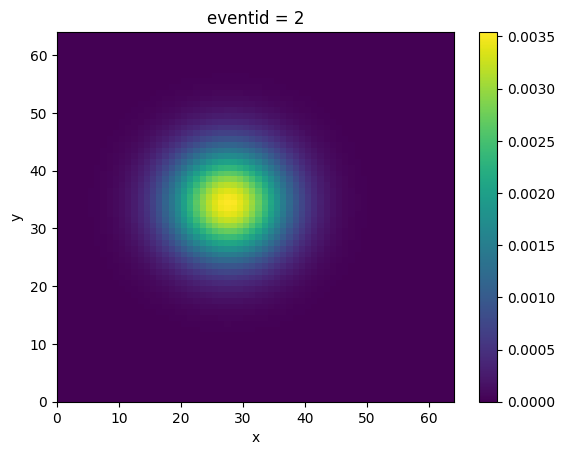

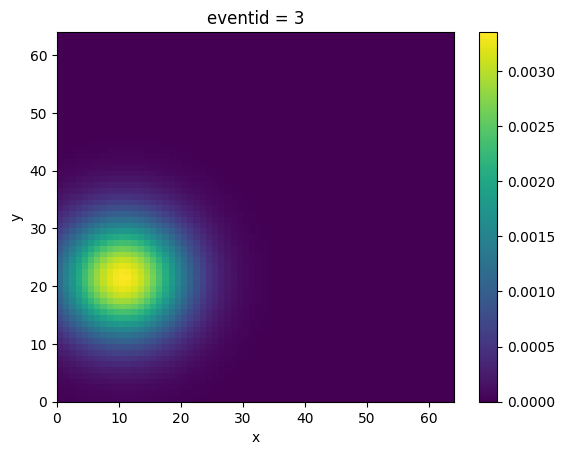

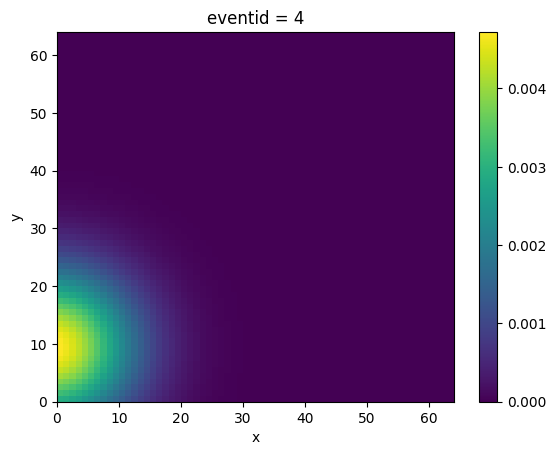

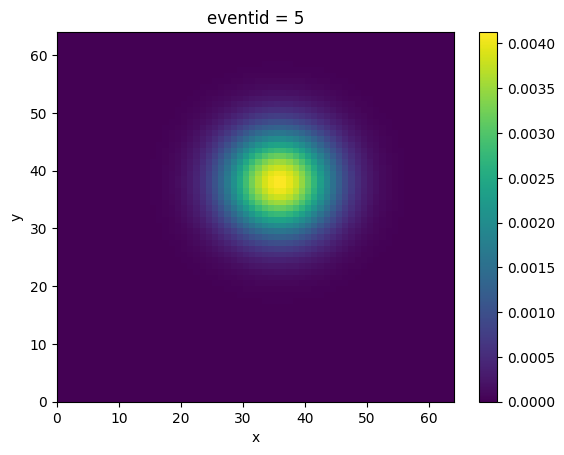

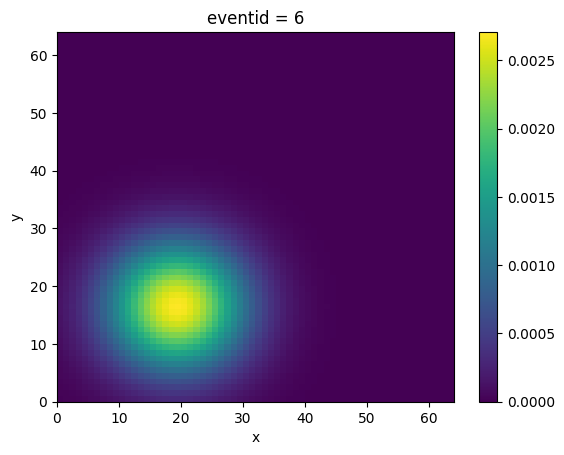

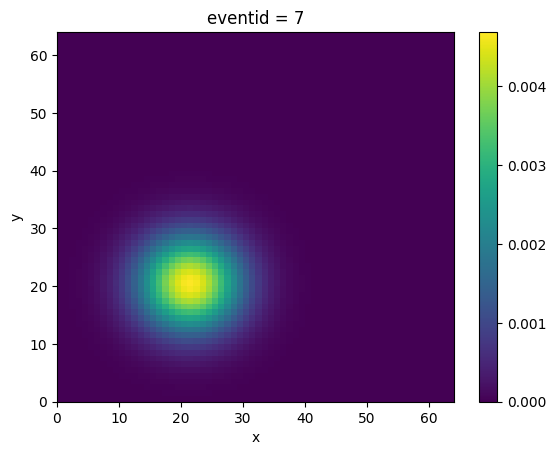

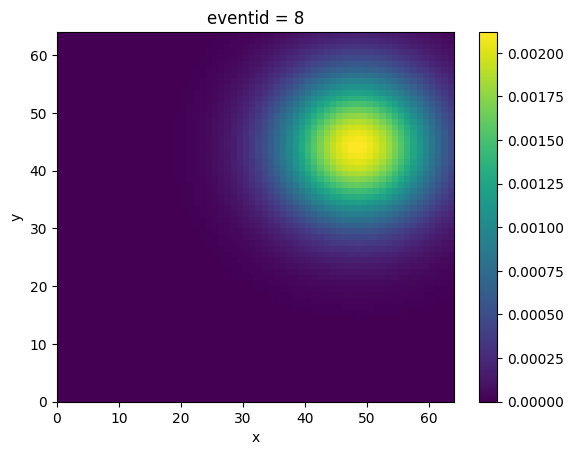

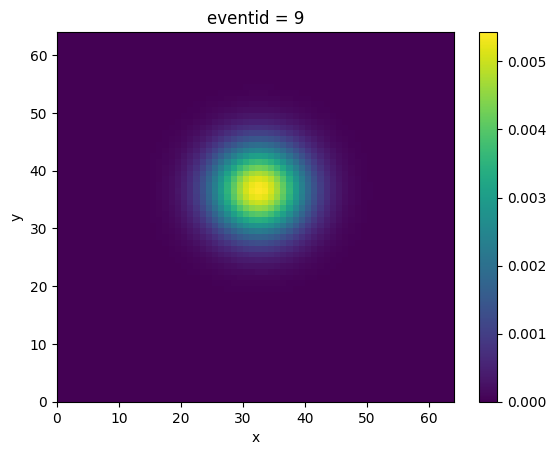

In [18]:
# Visualization of example probability maps

for eventid in range(0, 10):

    this_probability_map = probability_map_list.slice[{'eventid': eventid}].project(['x', 'y'])
        
    ax, _ = this_probability_map.draw()

    ax.set_title(f'eventid = {eventid}')

Text(0.5, 1.0, 'stacked probability map')

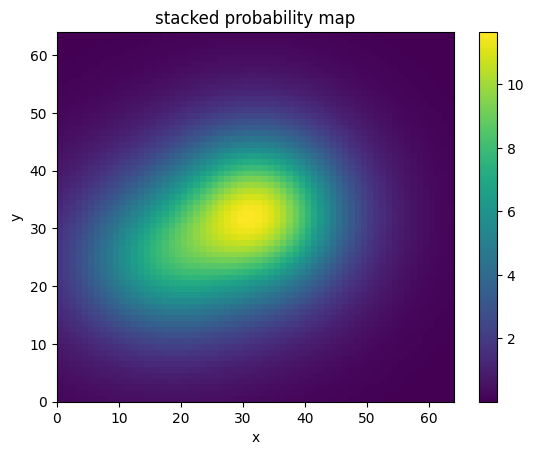

In [19]:
# Visualization of stacked probability map
summed_probability_map = probability_map_list.project(['x', 'y'])

ax, _ = summed_probability_map.draw()
ax.set_title("stacked probability map")

# 4. Defining Model and DataInterface classes for cosipy.image_deconvolution

## Model

Here we implement a custom image model class for cosipy's deconvolution framework.
The model class must inherit from ModelBase and implement required methods for:
- Model instantiation from parameters
- Setting model values based on parameters

This implementation provides a basic 2D image model suitable for our unbinned deconvolution problem, with initial flat-value initialization.

Key aspects of this model implementation:

- Inherits from cosipy.image_deconvolution.ModelBase
- `instantiate_from_parameters` and `set_values_from_parameters` must be overrided

In [20]:
from cosipy.image_deconvolution import ModelBase

15:30:33 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=788061;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=932900;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=886572;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=326088;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=703882;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=973228;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

         INFO      Starting 3ML!                                                                     ]8;id=646010;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=861807;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#39\39]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=534909;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=691254;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#40\40]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=98048;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=263007;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=400122;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=501772;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=733034;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=619737;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=466981;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=859254;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=165675;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=407005;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [21]:
class Image2D_Model(ModelBase):
    """2D image model for unbinned deconvolution.
    
    Inherits from cosipy's ModelBase class to provide a model compatible
    with the deconvolution framework.
    
    Attributes:
        axes (Axes): Histogram axes defining the image space
    """
    
    def __init__(self, nx, ny):
        """
        Initialize the image model.
        
        Args:
            nx (int): Number of bins in x dimension
            ny (int): Number of bins in y dimension
        """
        axes = Axes([np.linspace(0, nx, nx+1), np.linspace(0, ny, ny+1)], labels = ['x', 'y'])
        super().__init__(axes, sparse = False)

    @classmethod
    def instantiate_from_parameters(cls, parameter):
        """
        Create a new model instance from parameters.
        
        Args:
            parameter (dict): Dictionary containing model parameters
                Required keys:
                - 'nx': Number of x bins
                - 'ny': Number of y bins
        
        Returns:
            Image2D_Model: New model instance
        """
        nx = parameter['nx']
        ny = parameter['ny']

        new = cls(nx, ny)

        return new
        
    def set_values_from_parameters(self, parameter):
        """
        Set model values based on parameters.
        
        Args:
            parameter (dict): Dictionary containing:
                - 'algorithm': String identifying initialization method
                - 'parameter': Dictionary of algorithm-specific parameters
        """      
        algorithm_name = parameter['algorithm']
        algorithm_parameter = parameter['parameter']

        if algorithm_name == "flat":
            self[:] = algorithm_parameter['value']

(<Axes: xlabel='x', ylabel='y'>,
 <matplotlib.collections.QuadMesh at 0x174b56440>)

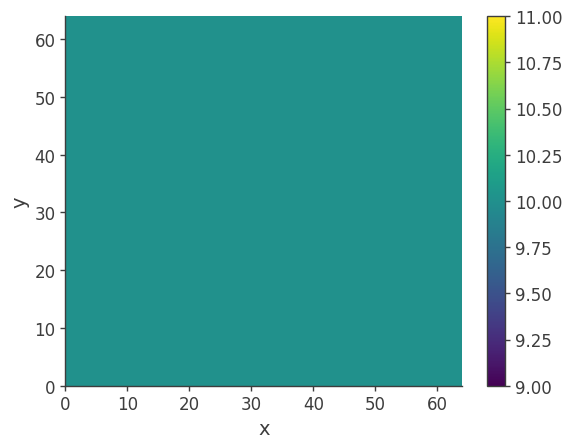

In [22]:
# Test the model implementation

init_parameter = {'nx': nx, 'ny': ny}
model = Image2D_Model.instantiate_from_parameters(init_parameter)

set_values_parameter = {'algorithm': 'flat', 'parameter': {'value': 10}}
model.set_values_from_parameters(set_values_parameter)

model.draw()

## DataInterface

This chapter implements the data interface for unbinned deconvolution in cosipy.
The data interface connects our measurement data (probability maps for each event)
with the deconvolution algorithm. It provides methods to:
- Calculate expected counts from a model
- Compute likelihood
- Handle the transition between model and data space

For unbinned analysis, the interface needs to properly manage individual event
probabilities and their relationship to the model space.

Key aspects of this model implementation:

- Inherits from cosipy.image_deconvolution.ImageDeconvolutionDataInterfaceBase
- Manages probability maps and efficiency information
- Handles transformations between model and data spaces

Core Operations:
- calc_expectation: Computes event probabilities from model
- calc_T_product: Handles adjoint transformation
- calc_log_likelihood: Evaluates fit quality

In [23]:
from cosipy.image_deconvolution import ImageDeconvolutionDataInterfaceBase

In [24]:
class DataIF_Image2D_Unbinned(ImageDeconvolutionDataInterfaceBase):
    """
    Data interface for unbinned image deconvolution.
    
    Implements the connection between probability maps and the deconvolution
    algorithm, handling all data-model calculations.
    """
    def __init__(self, probability_map_list, efficiency_map, name = None):
        """
        Initialize the data interface.
        
        Args:
            probability_map_list (Histogram): 3D histogram of probability maps
            efficiency_map (Histogram): 2D detector efficiency map
            name (str, optional): Interface identifier
        """        
        ImageDeconvolutionDataInterfaceBase.__init__(self, name)
        self._probability_map_list = probability_map_list
        self._exposure_map = efficiency_map

        # Define axes for model and data spaces
        self._model_axes = probability_map_list.axes[['x', 'y']]
        self._data_axes = probability_map_list.axes[['eventid']]

        # Initialize event histogram (all weights=1 for unbinned case)
        self._event = Histogram(self.data_axes, 
                                np.ones(probability_map_list.axes['eventid'].nbins))
        
        # Placeholder for background models (not implemented in this tutorial)
        self._bkg_models = {} # TBD        
        self._summed_bkg_models = {} # TBD

    def calc_expectation(self, model, dict_bkg_norm = None, almost_zero = 1e-12):
        """
        Calculate expected probabilities for all events given a model.
        
        Args:
            model (Histogram): Current model image
            dict_bkg_norm (dict, optional): Background normalizations
            almost_zero (float, optional): Minimum probability value
            
        Returns:
            Histogram: Expected probabilities for each event
        """
        return Histogram(self.data_axes, 
                         np.tensordot(self._probability_map_list[:], model[:], axes = ([1,2], [0,1])))
    
    def calc_T_product(self, dataspace_histogram):
        """
        Backprojection from data space to model space.
        
        Args:
            dataspace_histogram (Histogram): Values in data space
            
        Returns:
            Histogram: Values mapped to model space
        """
        return Histogram(self.model_axes,
                         np.tensordot(self._probability_map_list[:], dataspace_histogram[:], axes = ([0], [0])))
    
    def calc_bkg_model_product(self, key, dataspace_histogram):
        #TBD
        return 0
    
    def calc_log_likelihood(self, expectation):
        """Calculate log likelihood for current model.
        
        Args:
            expectation (Histogram): Expected probabilities
            
        Returns:
            float: Log likelihood value

        Notes:
            Correctly, the output seems to be np.sum(np.log(expectation)) - np.sum(model*self.exposure_map).
            To do this, calc_log_likelihood should have `model` as its input parameter. We need to modify this function that way in the future.
        """
        return np.sum(np.log(expectation))

Event data shape: (10000,)
Sample expectation: [0.00140639 0.02482515 0.0277548  ... 0.02231945 0.0131421  0.01794504]


(<Axes: xlabel='x', ylabel='y'>,
 <matplotlib.collections.QuadMesh at 0x35546ac80>)

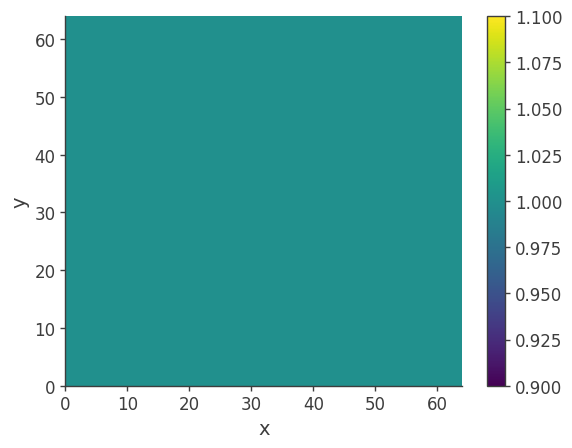

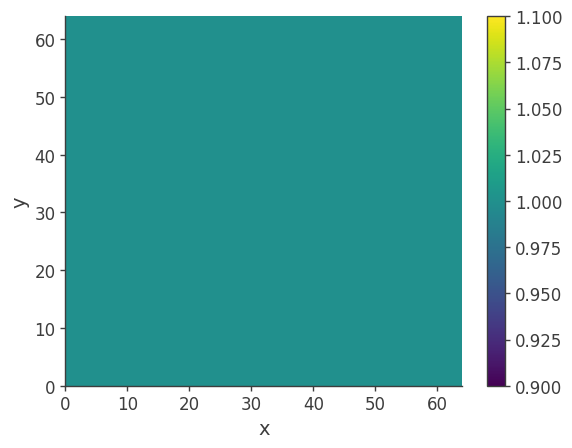

In [25]:
# Create and test the data interface

axes = Axes([np.linspace(0, nx, nx+1), np.linspace(0, ny, ny+1)], labels = ['x', 'y'])
efficiency_map = Histogram(axes, track_overflow = False)
efficiency_map[:] = 1 # Uniform efficiency for this tutorial
efficiency_map.draw()

dataIF = DataIF_Image2D_Unbinned(probability_map_list, efficiency_map, name = 'data_test')

# Test basic operations
print("Event data shape:", dataIF.event[:].shape)
print("Sample expectation:", dataIF.calc_expectation(true_image)[:])
dataIF.exposure_map.draw()

# 4. Image Deconvolution

This final chapter executes the image deconvolution using the cosipy framework
and evaluates the results. We use the Richardson-Lucy algorithm, which is well-suited
for Poisson statistics and naturally maintains non-negativity in the reconstruction.

The deconvolution process:
1. Initialize the framework with our custom model and data interface
2. Configure the algorithm parameters
3. Run the iterative reconstruction
4. Visualize and evaluate the results

In [26]:
from cosipy.image_deconvolution import ImageDeconvolution

In [27]:
# Register our custom model class
ImageDeconvolution.model_classes['Image2D_Model'] = Image2D_Model

In [28]:
# Create and configure deconvolution instance
image_deconvolution = ImageDeconvolution()
image_deconvolution.set_dataset([dataIF])
image_deconvolution.read_parameterfile("image_deconvolution_parameter.yaml")
image_deconvolution.initialize()

#### Initialization Starts ####
<< Instantiating the model class Image2D_Model >>
---- parameters ----
nx: 64
ny: 64

<< Setting initial values of the created model object >>
---- parameters ----
algorithm: flat
parameter:
  value: 1

<< Registering the deconvolution algorithm >>
A directory ./results already exists. Files in ./results may be overwritten. Make sure that is not a problem.
---- parameters ----
algorithm: RL
parameter:
  acceleration:
    activate: true
    alpha_max: 100.0
  background_normalization_optimization:
    activate: false
    range:
      albedo:
      - 0.9
      - 1.1
  iteration_max: 100
  minimum_flux:
    value: 0.0
  response_weighting:
    activate: true
    index: 0.5
  save_results:
    activate: true
    directory: ./results
    only_final_result: false
  smoothing:
    FWHM:
      unit: deg
      value: 2.0
    activate: false
  stopping_criteria:
    statistics: log-likelihood
    threshold: 1

#### Initialization Finished ####


In [29]:
# Run deconvolution
image_deconvolution.run_deconvolution()

#### Image Deconvolution Starts ####
<< Initialization >>
The response weighting filter was calculated.
The expected count histograms were calculated with the initial model map.


  0%|          | 0/100 [00:00<?, ?it/s]

## Iteration 1/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>
<< Registering Result >>
  alpha: 1.0078632821933817
  background_normalization: {}
  log-likelihood: [17062.59587466684]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 2/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>
<< Registering Result >>
  alpha: 1.0069228361062494
  background_normalization: {}
  log-likelihood: [18673.79225182608]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 3/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>
<< Registering Result >>
  alpha: 1.0140361274887468
  background_normalization: {}
  log-likelihood: [19259.126541707534]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 4/100 ##



WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide



<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>
<< Registering Result >>
  alpha: 1.0213040712356434
  background_normalization: {}
  log-likelihood: [19541.56228688973]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 5/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>
<< Registering Result >>
  alpha: 1.0297892965693576
  background_normalization: {}
  log-likelihood: [19706.122693408397]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 6/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>
<< Registering Result >>
  alpha: 1.038233374819787
  background_normalization: {}
  log-likelihood: [19814.070542711575]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 7/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>
<< Registering Result >>
  alpha: 1.0455518601504403
  background_normalization: {}
  log-likelihood: [19890.692854289686]
<< Checking Stopping Criteria 

...

<< Post-processing >>
<< Registering Result >>
  alpha: 1.153571621122996
  background_normalization: {}
  log-likelihood: [20311.483015298687]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 58/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>
<< Registering Result >>
  alpha: 1.154809302159995
  background_normalization: {}
  log-likelihood: [20312.588711725566]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 59/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>
<< Registering Result >>
  alpha: 1.1584348949805288
  background_normalization: {}
  log-likelihood: [20313.659402640762]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 60/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>



WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide



<< Post-processing >>
<< Registering Result >>
  alpha: 1.1598856272482758
  background_normalization: {}
  log-likelihood: [20314.694766489138]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 61/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>
<< Registering Result >>
  alpha: 1.1617876398801805
  background_normalization: {}
  log-likelihood: [20315.69690104102]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 62/100 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>
<< Registering Result >>
  alpha: 1.1629210062540083
  background_normalization: {}
  log-likelihood: [20316.666730235236]
<< Checking Stopping Criteria >>
--> Stop
<< Finalization >>
Saving results in ./results



WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide



#### Image Deconvolution Finished ####


10000.0


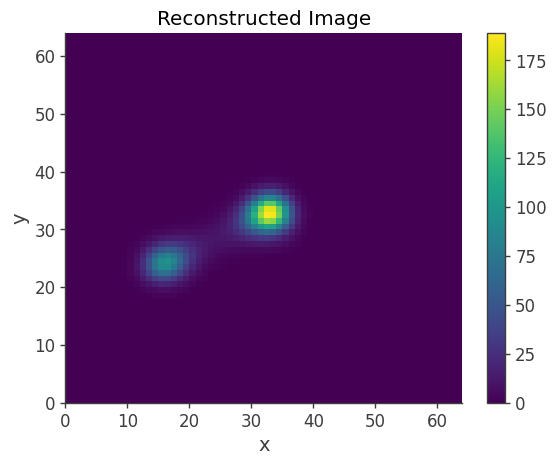

In [30]:
# Visualize the reconstructed image
ax, _ = image_deconvolution.results[-1]['model'].draw()
ax.set_title(f'Reconstructed Image')
print(np.sum(image_deconvolution.results[-1]['model']))

10046.424818069725


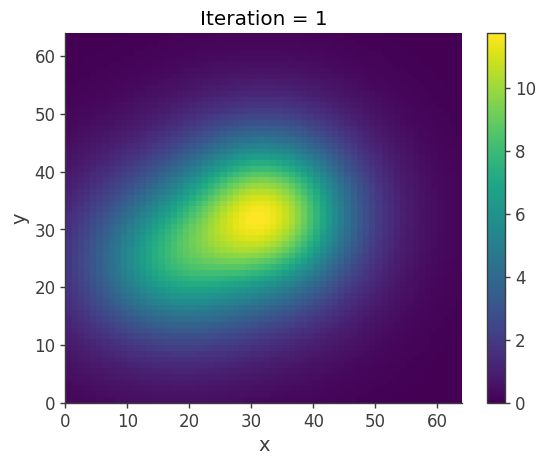

9999.67860859324


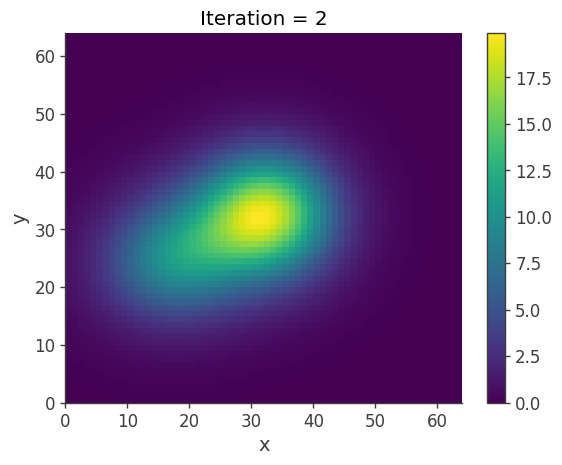

10000.00451109076


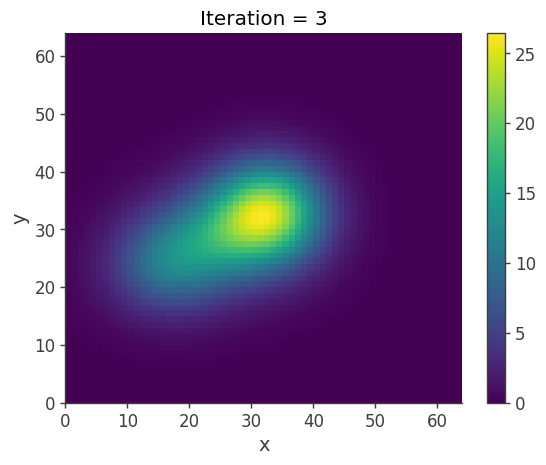

9999.999903895401


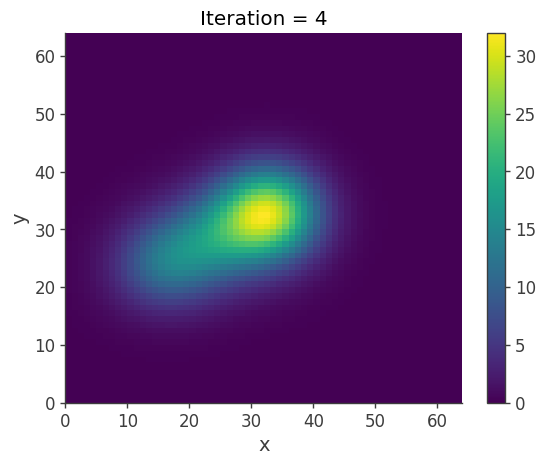

10000.00000286289


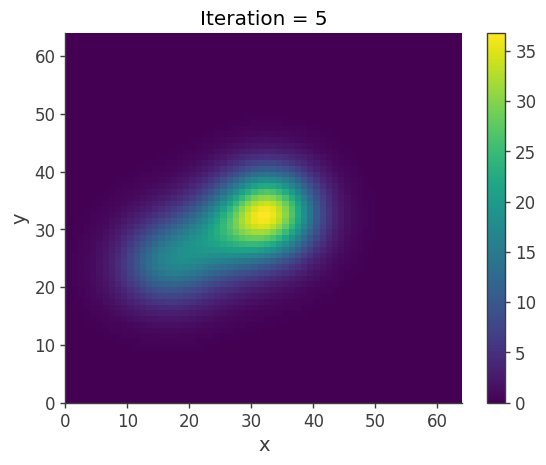

9999.999999890544


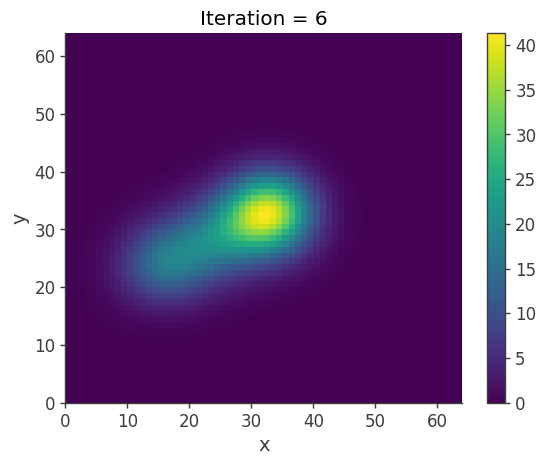

10000.000000004986


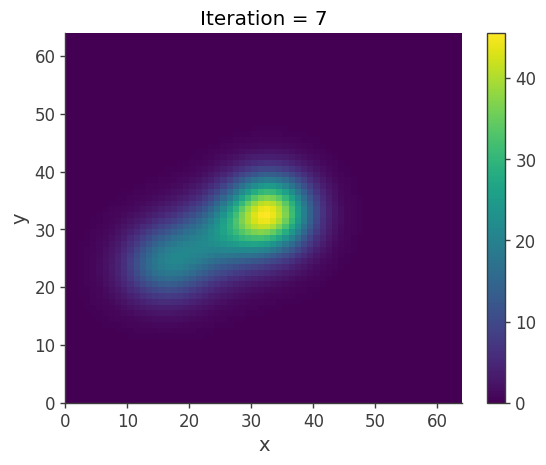

9999.999999999749


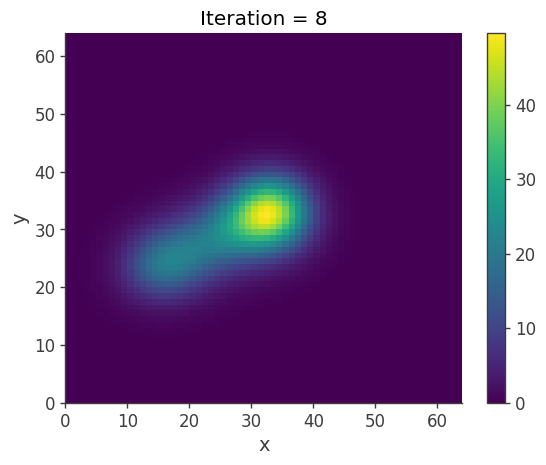

10000.000000000015


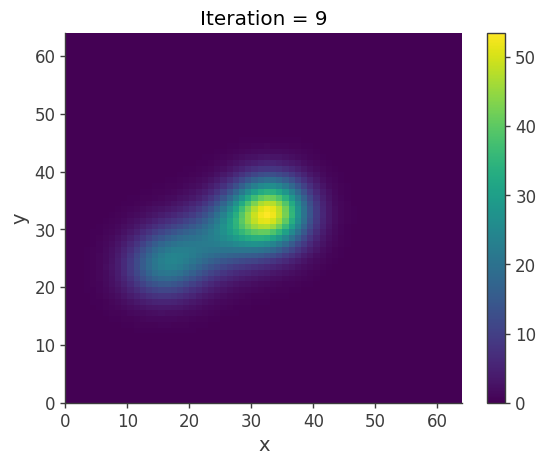

10000.0


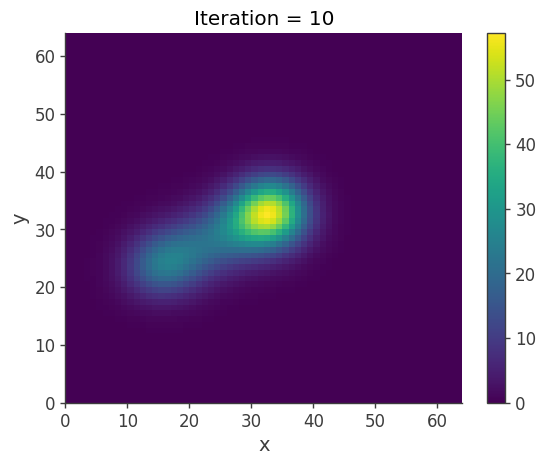

10000.000000000002


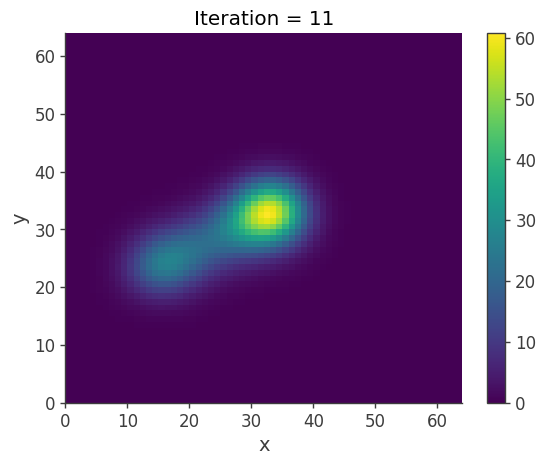

10000.000000000004


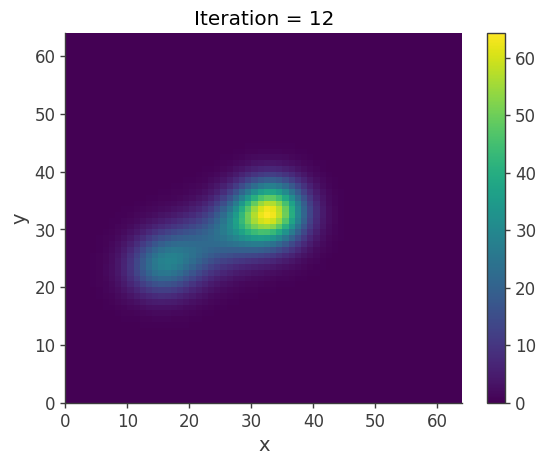

10000.000000000004


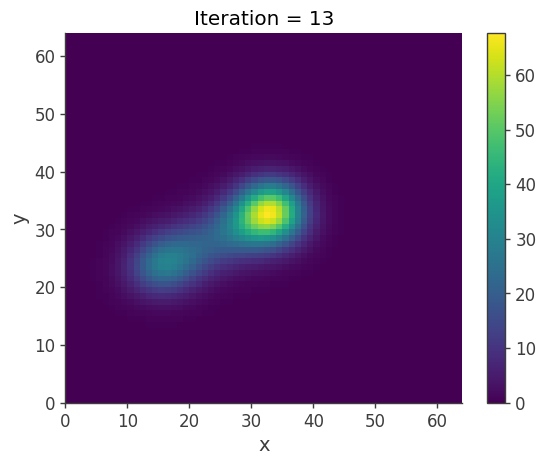

10000.000000000002


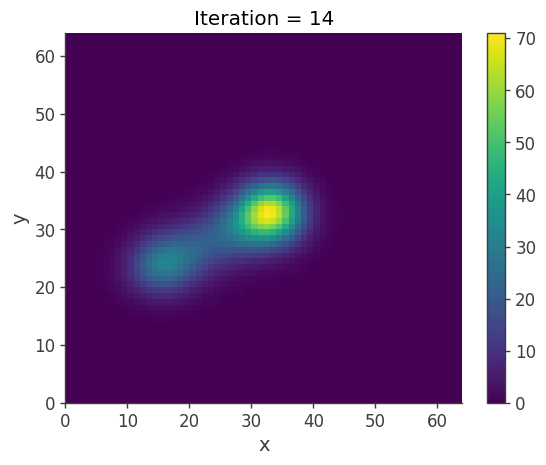

10000.0


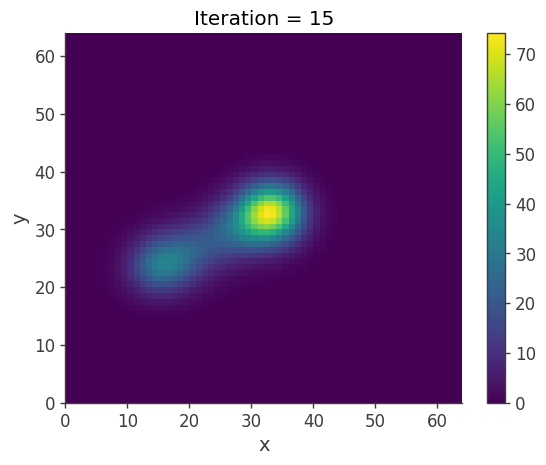

10000.000000000004


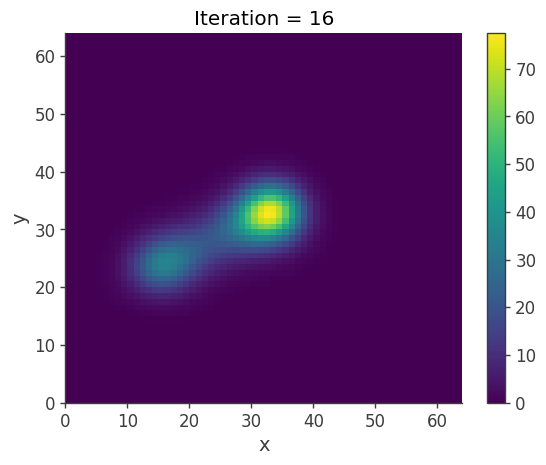

10000.000000000005


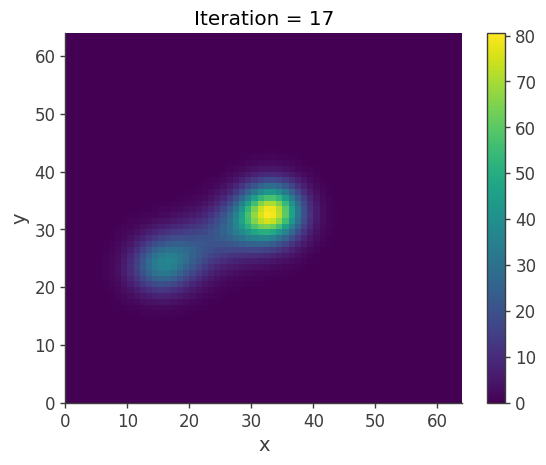

10000.000000000002


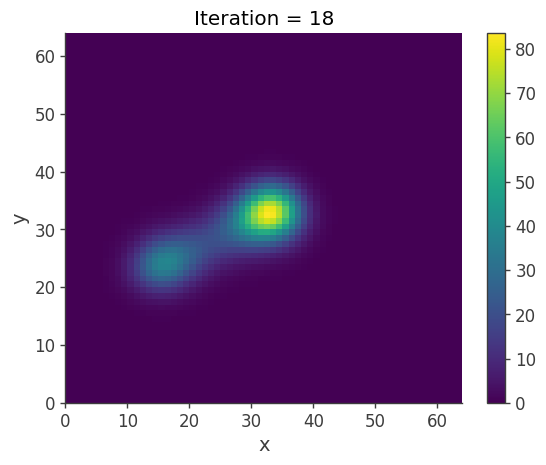

10000.0


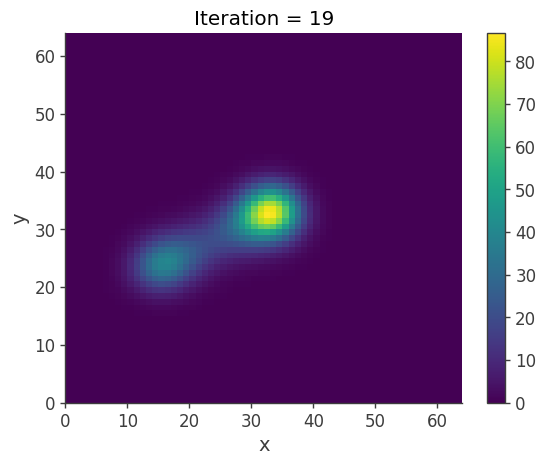

10000.000000000002


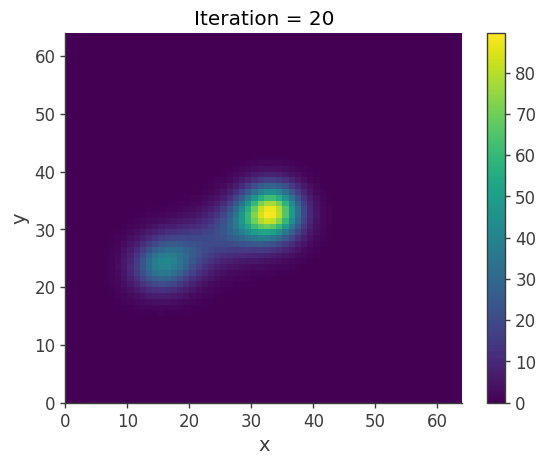

10000.0


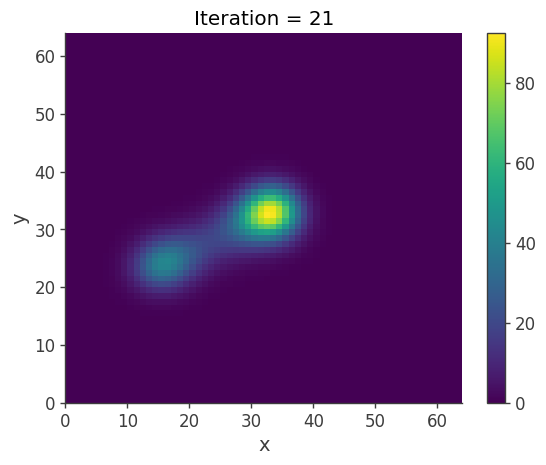

10000.000000000004


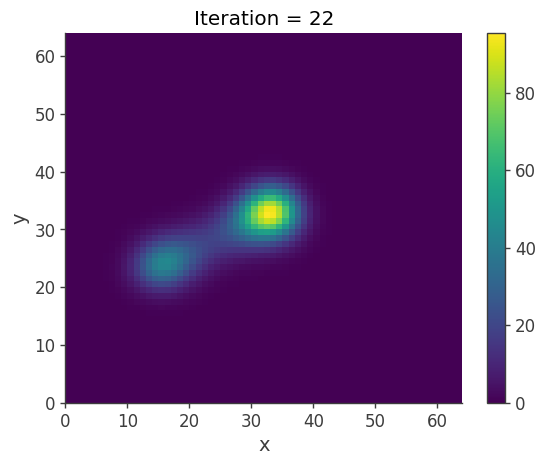

10000.000000000002


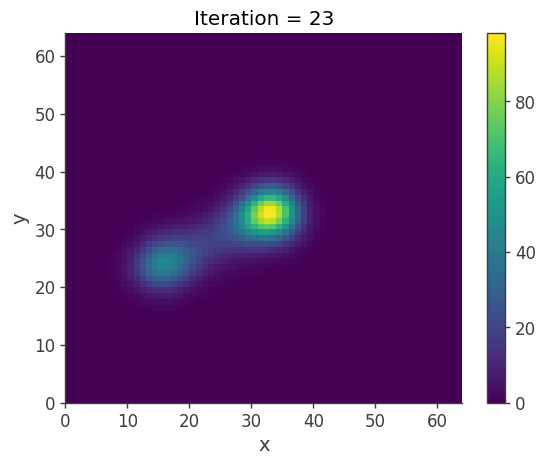

10000.000000000004


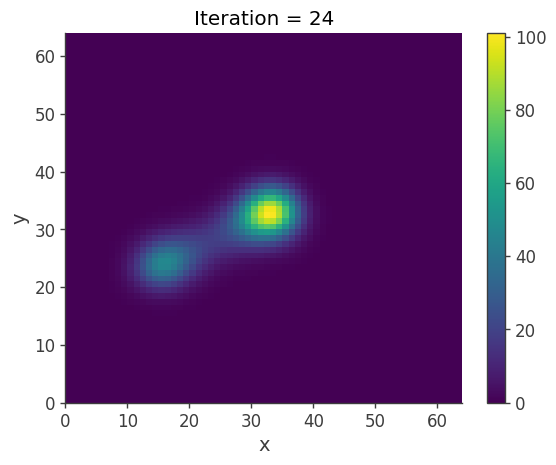

10000.000000000004


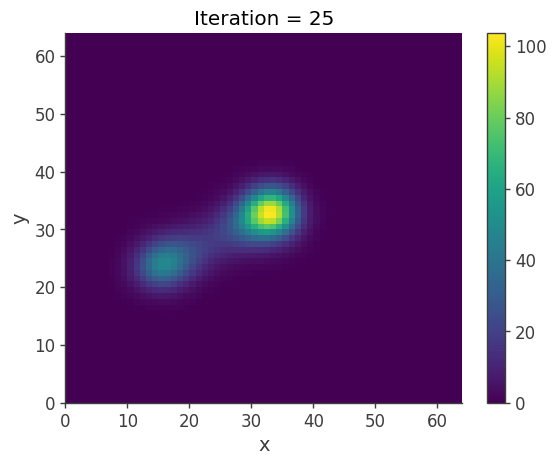

10000.000000000004


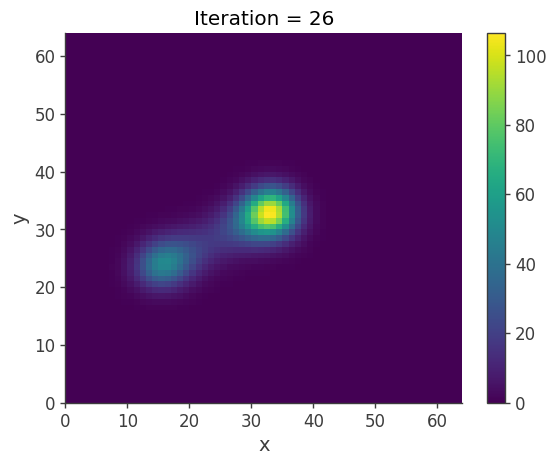

10000.000000000004


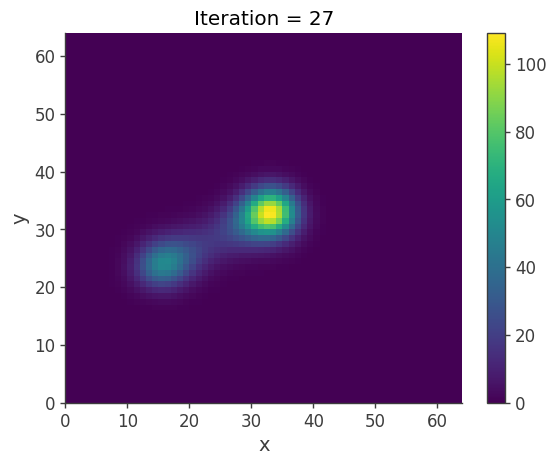

10000.000000000004


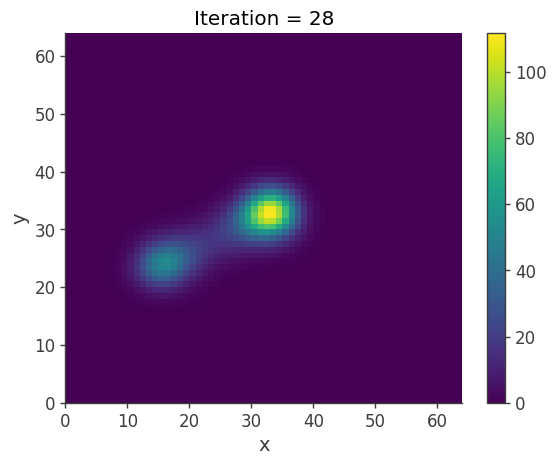

10000.000000000004


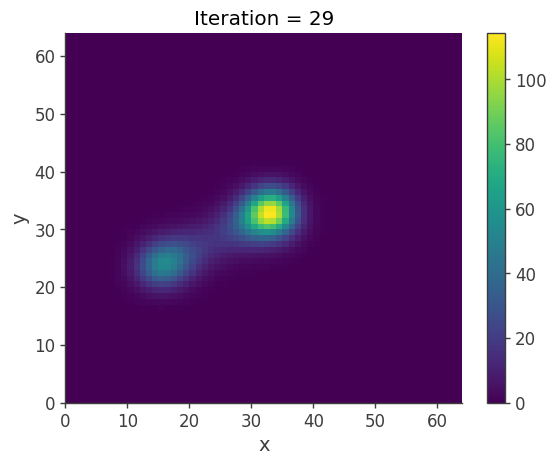

10000.000000000004


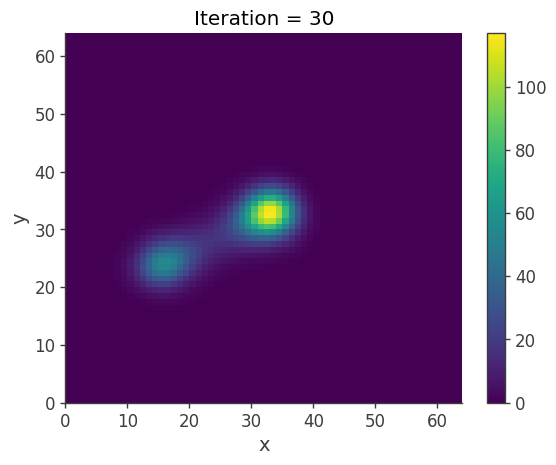

10000.000000000004


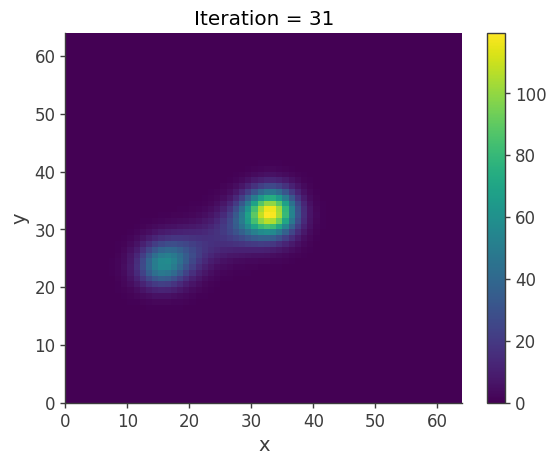

10000.0


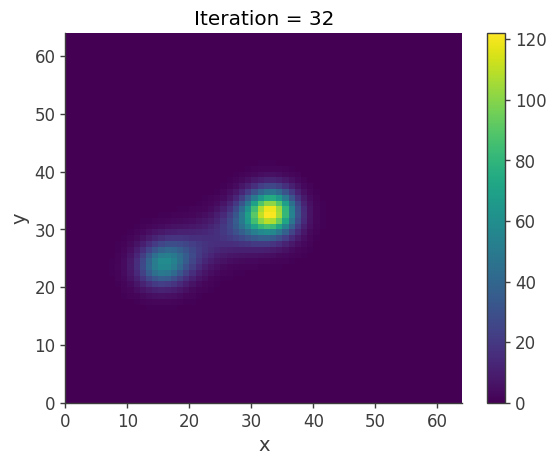

10000.0


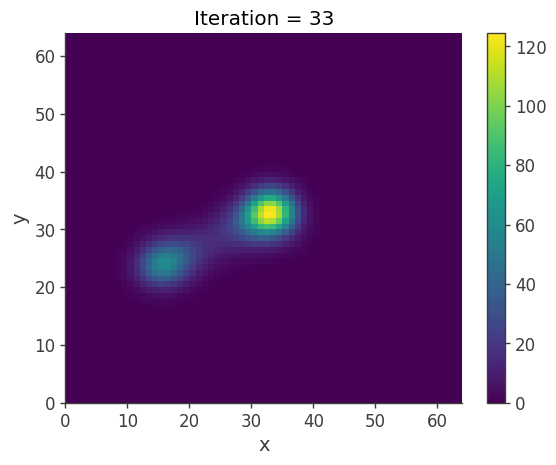

10000.000000000004


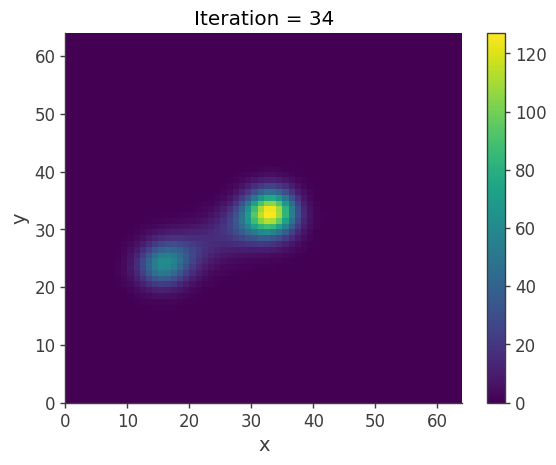

10000.000000000004


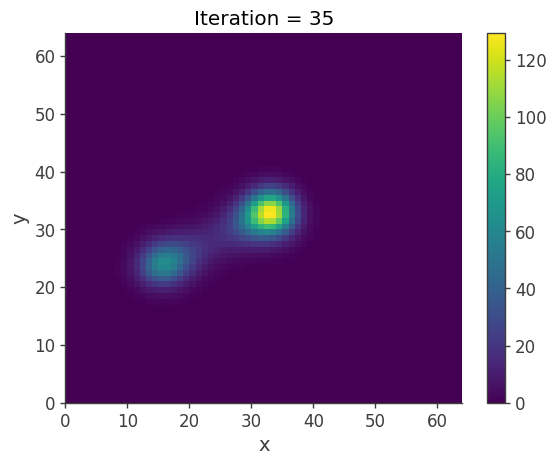

10000.000000000002


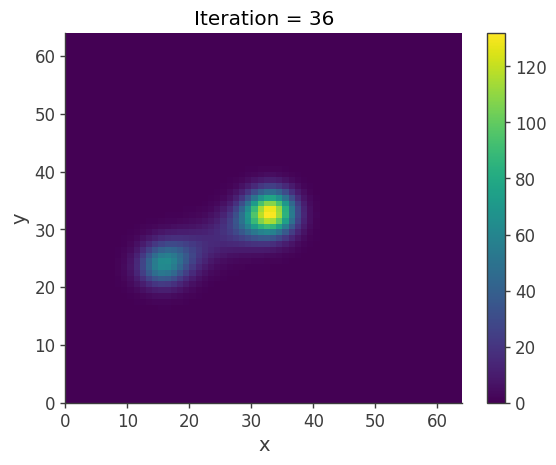

10000.0


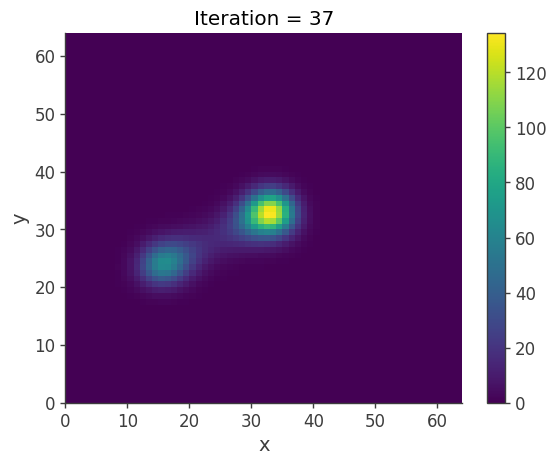

10000.000000000002


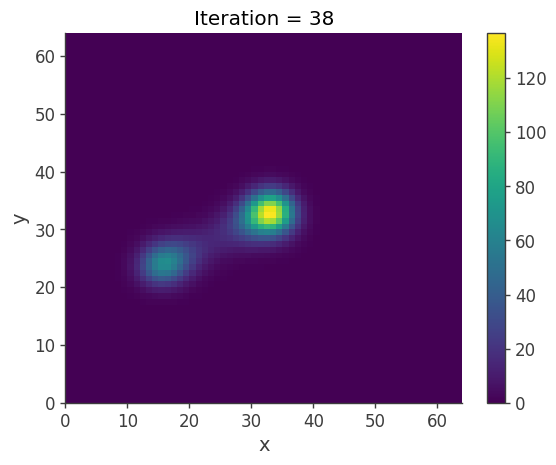

9999.999999999996


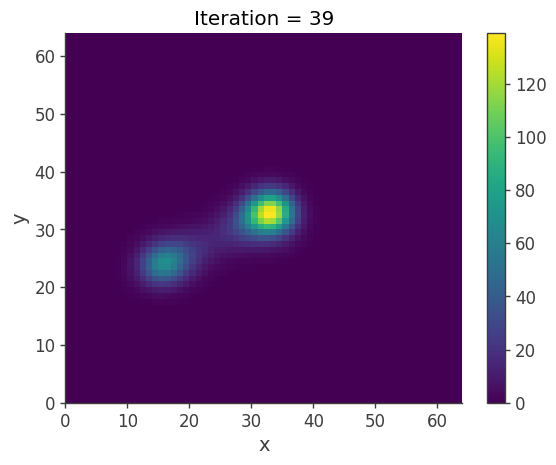

10000.000000000002


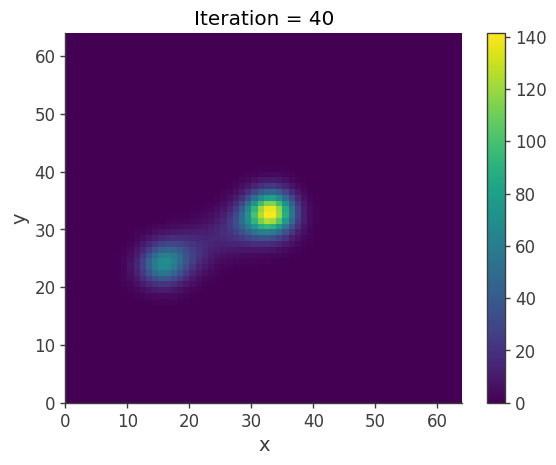

10000.000000000004


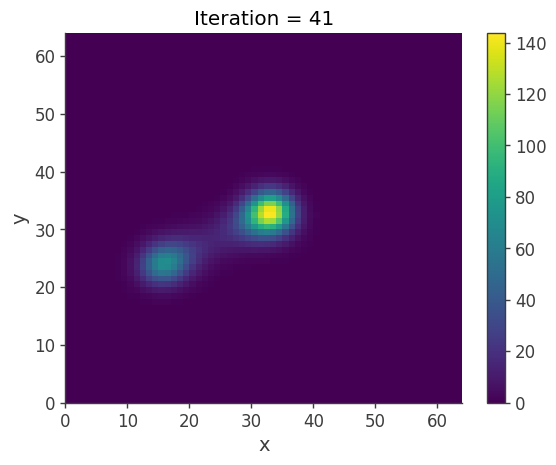

10000.000000000004


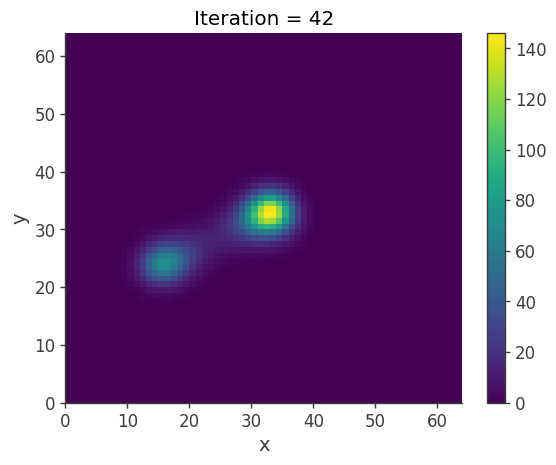

10000.000000000002


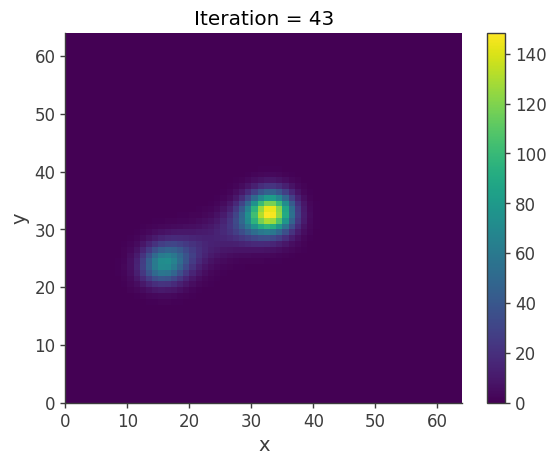

10000.000000000002


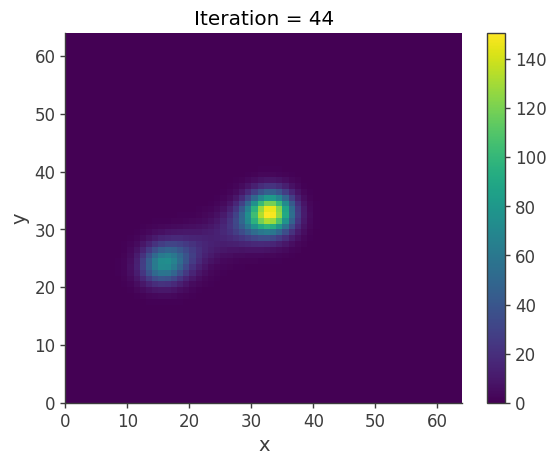

9999.999999999996


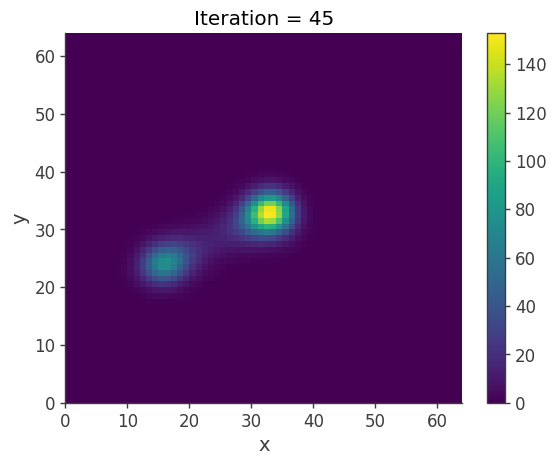

10000.000000000004


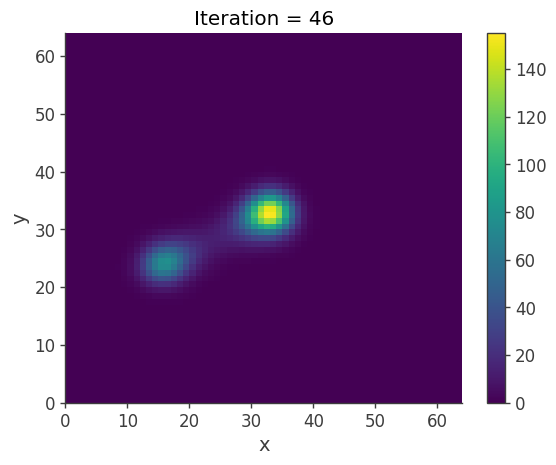

10000.000000000002


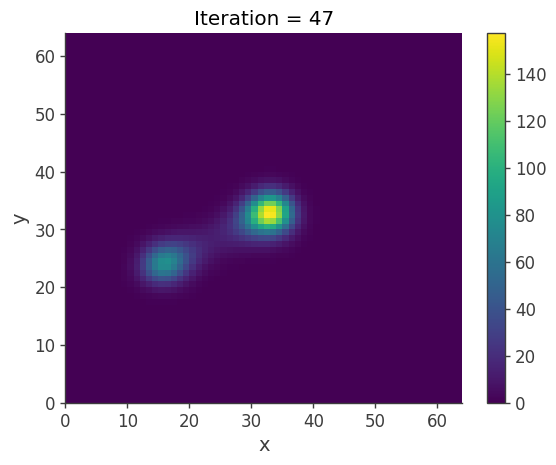

10000.0


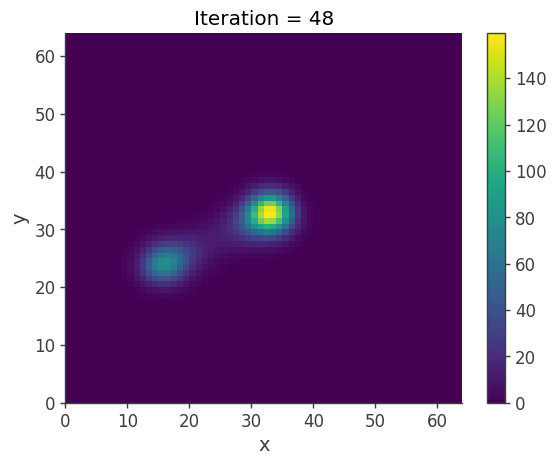

10000.0


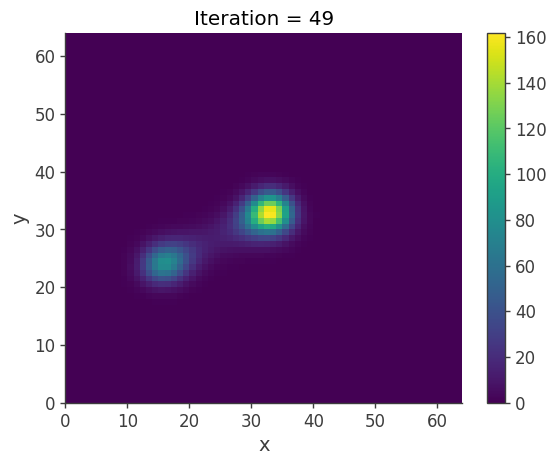

9999.999999999998


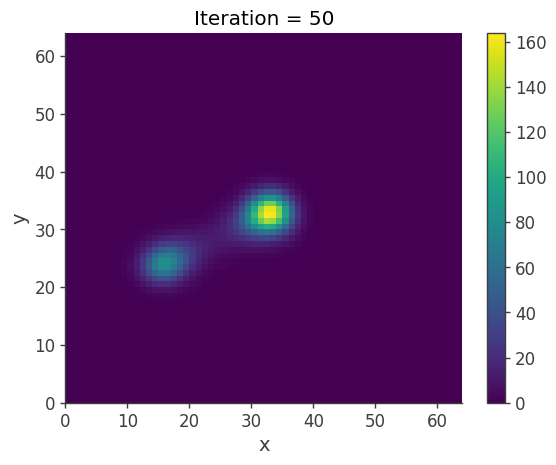

10000.000000000002


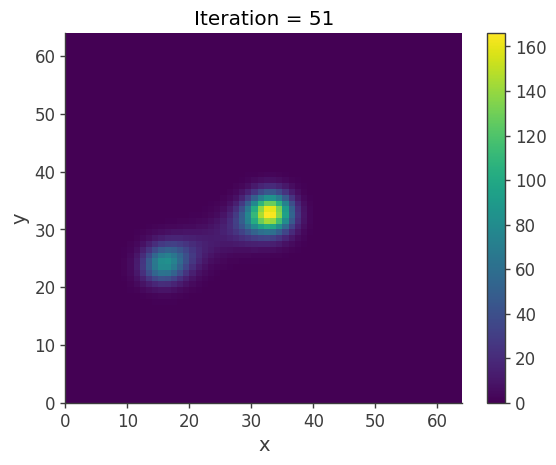

9999.999999999998


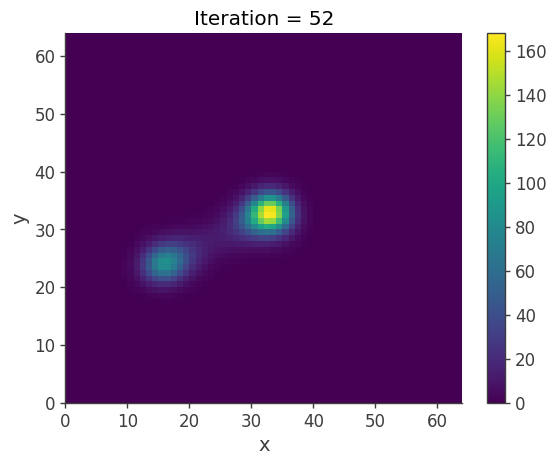

10000.000000000005


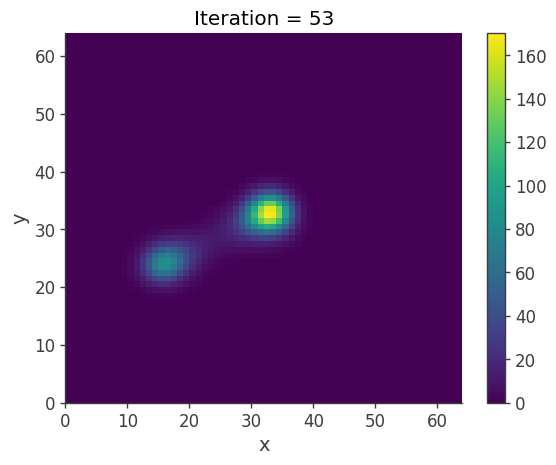

10000.000000000004


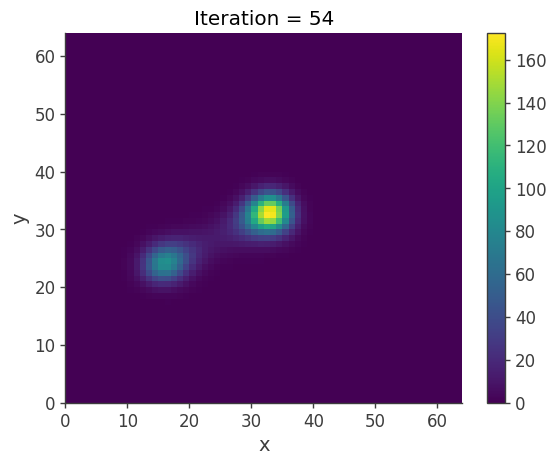

10000.0


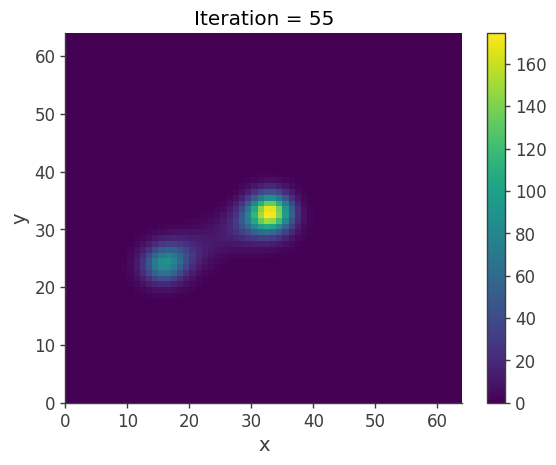

10000.000000000002


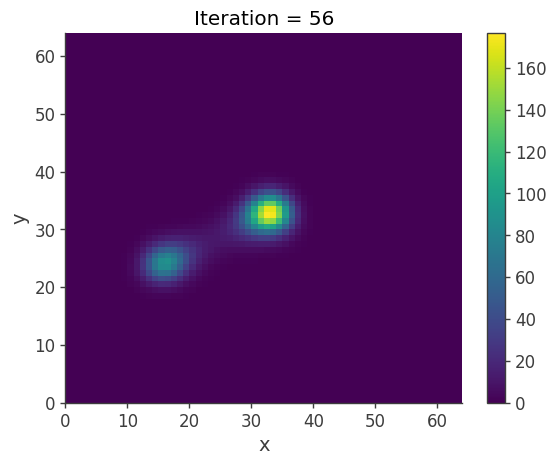

10000.000000000004


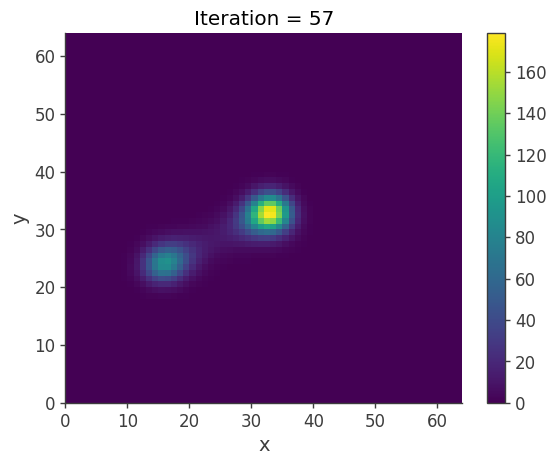

10000.000000000004


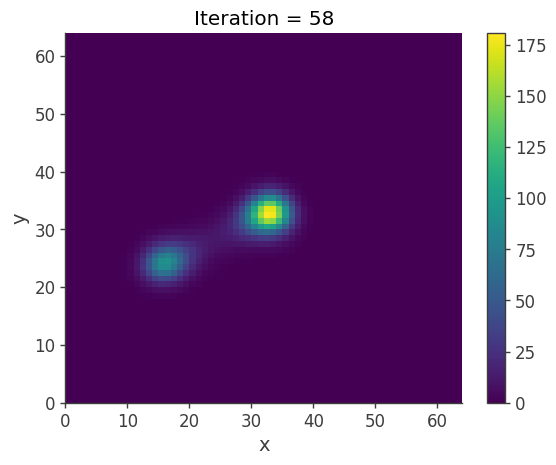

9999.999999999998


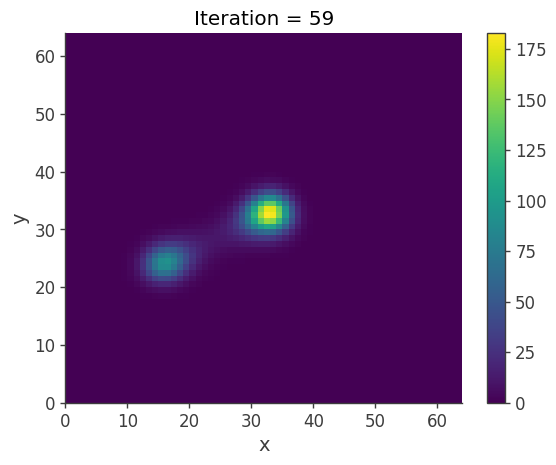

10000.000000000004


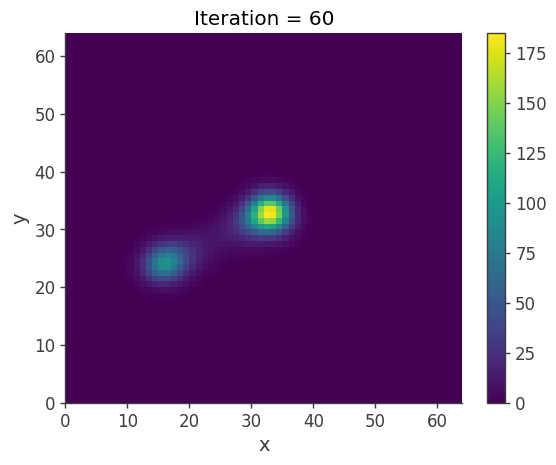

9999.999999999998


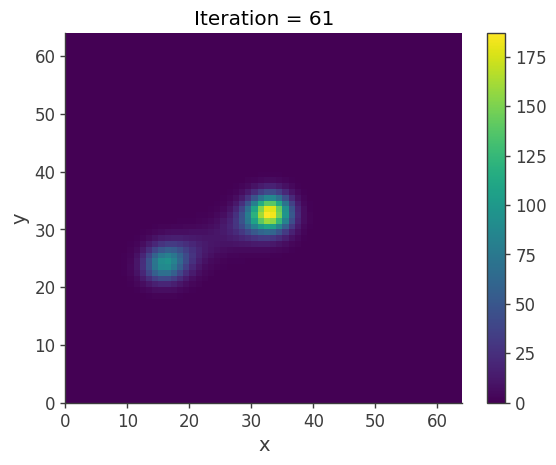

10000.0


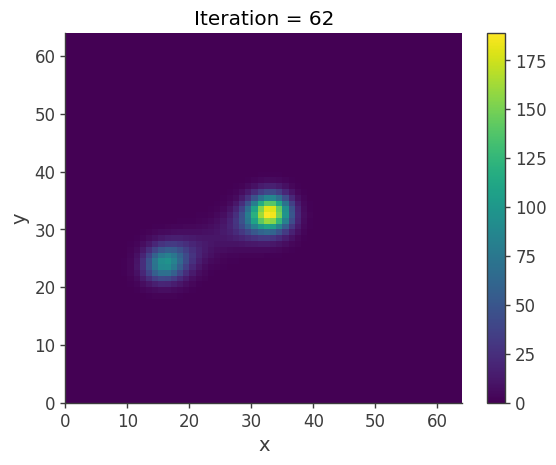

In [31]:
# Visualize results through iterations
for result in image_deconvolution.results:
    ax, _ = result['model'].draw()
    ax.set_title(f'Iteration = {result["iteration"]}')
    print(np.sum(result['model']))
    plt.show()

Text(0, 0.5, 'Log-likelihood')

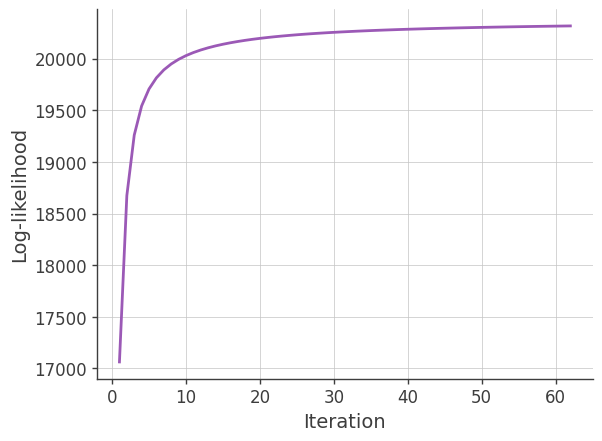

In [32]:
# Plot the likelihood curve

iterations = [result['iteration'] for result in image_deconvolution.results]
loglikelihoods = [result['log-likelihood'] for result in image_deconvolution.results]

plt.plot(iterations, loglikelihoods)
plt.grid()
plt.xlabel('Iteration')
plt.ylabel('Log-likelihood')

In [33]:
# we can see the results from the saved file

fitsfile = fits.open('results/results.fits')

for hdu in fitsfile:
    print(hdu.name)

PRIMARY
ALPHA
LOG-LIKELIHOOD


In [34]:
fitsfile[2].data

FITS_rec([( 1, 17062.59587467), ( 2, 18673.79225183),
          ( 3, 19259.12654171), ( 4, 19541.56228689),
          ( 5, 19706.12269341), ( 6, 19814.07054271),
          ( 7, 19890.69285429), ( 8, 19948.09810983),
          ( 9, 19992.90024087), (10, 20028.95963442),
          (11, 20058.66340321), (12, 20083.5906731 ),
          (13, 20104.85449259), (14, 20123.19584779),
          (15, 20139.21485613), (16, 20153.31099864),
          (17, 20165.80984234), (18, 20176.99890861),
          (19, 20187.04717119), (20, 20196.12818008),
          (21, 20204.37099853), (22, 20211.88903155),
          (23, 20218.77805684), (24, 20225.11071647),
          (25, 20230.95187138), (26, 20236.35977673),
          (27, 20241.37869117), (28, 20246.0507573 ),
          (29, 20250.41428113), (30, 20254.49714911),
          (31, 20258.32201994), (32, 20261.91425032),
          (33, 20265.29543528), (34, 20268.48890171),
          (35, 20271.50524372), (36, 20274.35656995),
          (37, 20277.0596624

Text(0, 0.5, 'Log-likelihood')

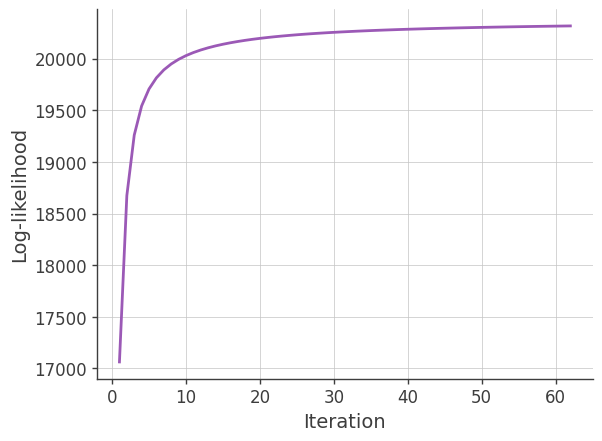

In [35]:
# Plot the likelihood curve

plt.plot(fitsfile[2].data['iteration'], fitsfile[2].data['data_test'])
plt.grid()
plt.xlabel('Iteration')
plt.ylabel('Log-likelihood')

10000.0


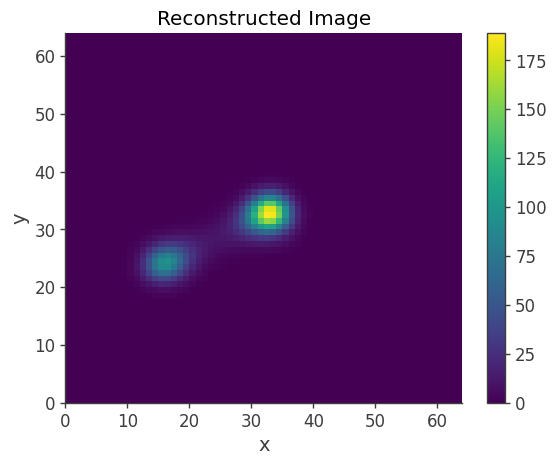

In [36]:
# Visualize the reconstructed image

image = Histogram.open('results/model.hdf5', 'result')

ax, _ = image.draw()
ax.set_title(f'Reconstructed Image')
print(np.sum(result['model']))

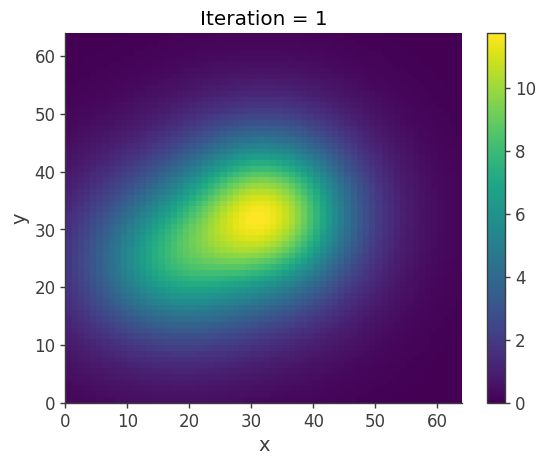

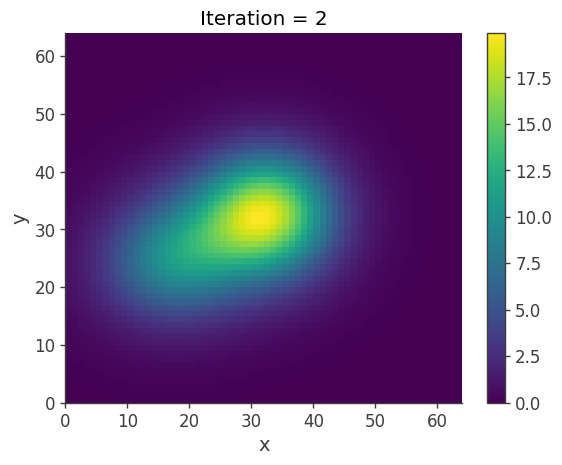

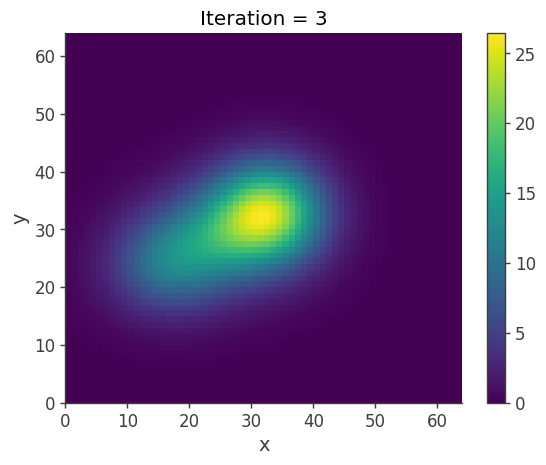

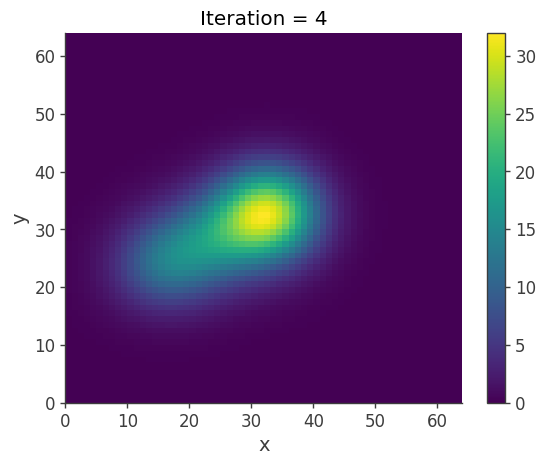

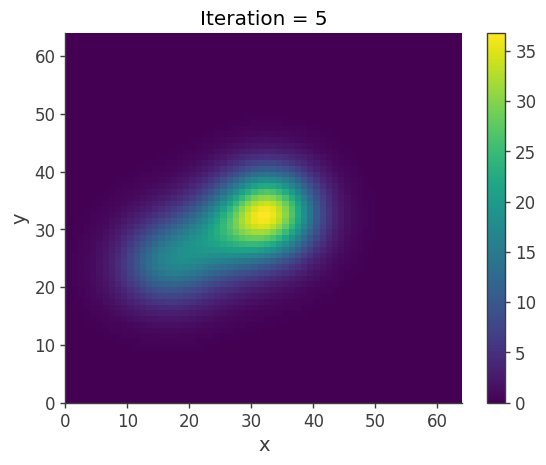

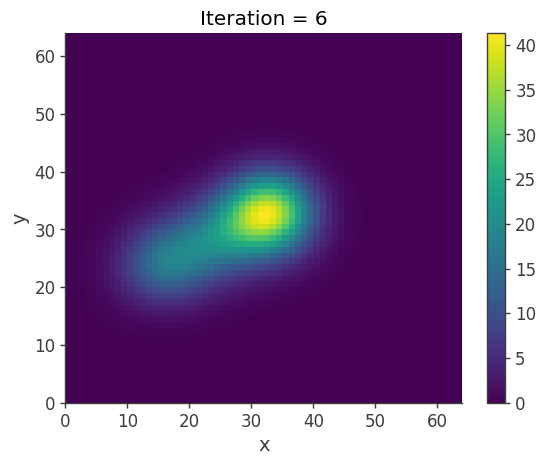

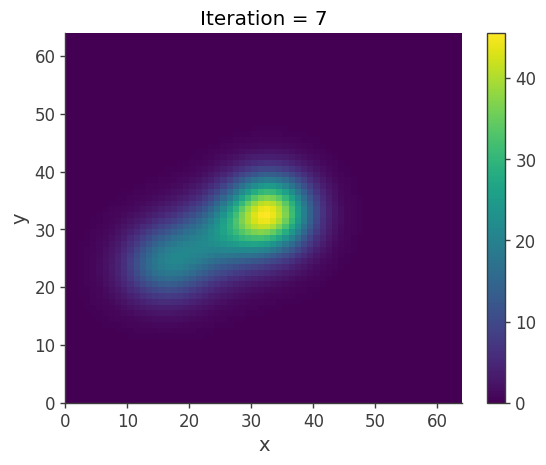

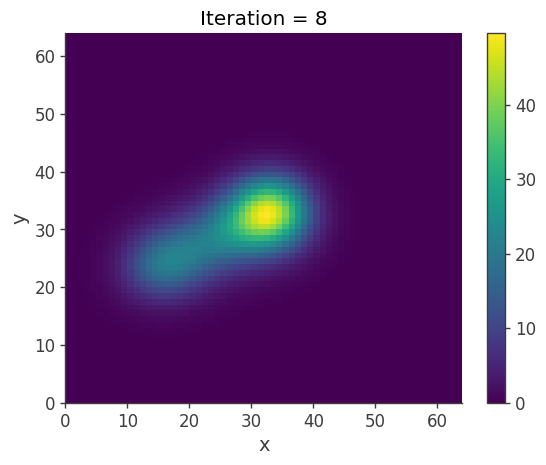

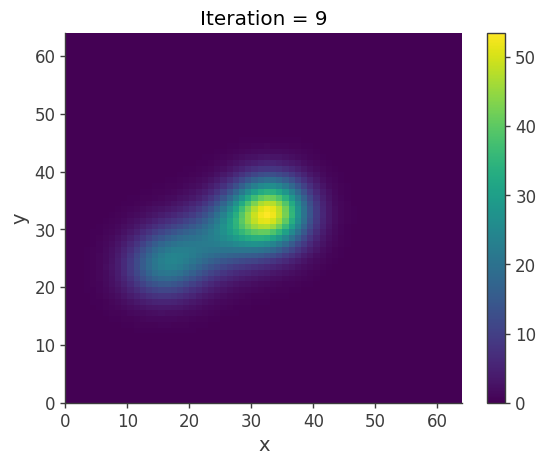

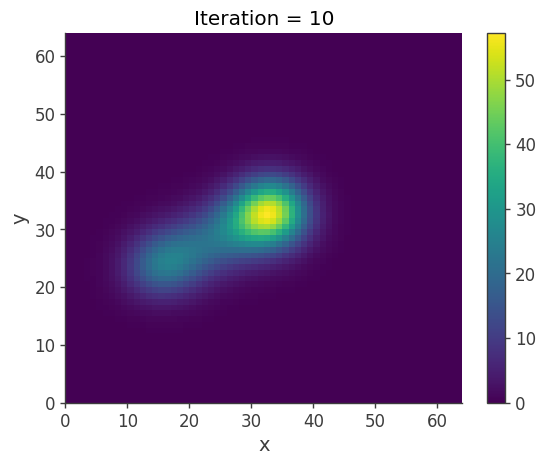

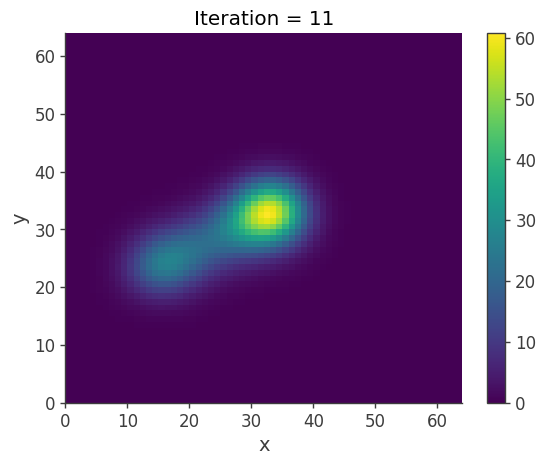

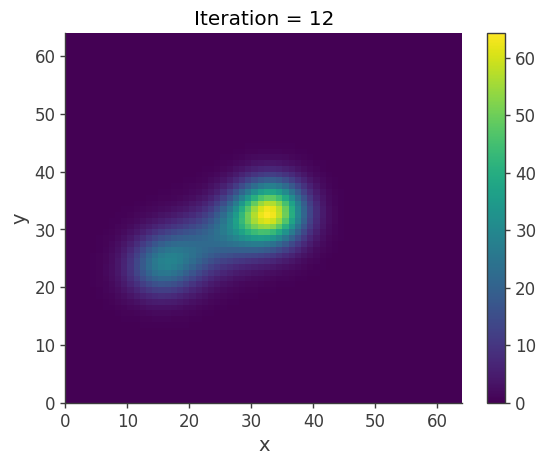

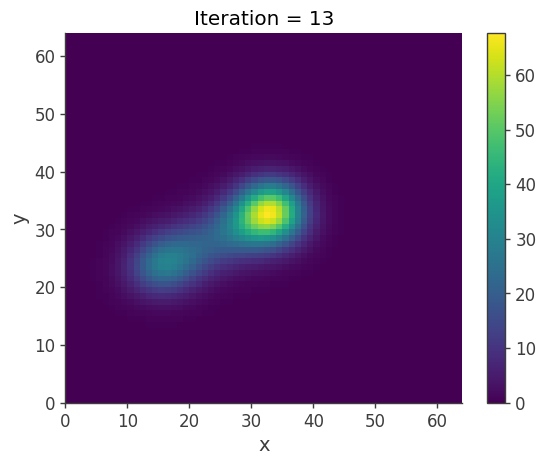

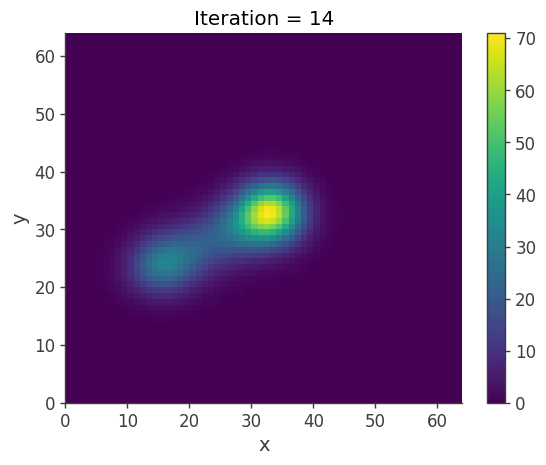

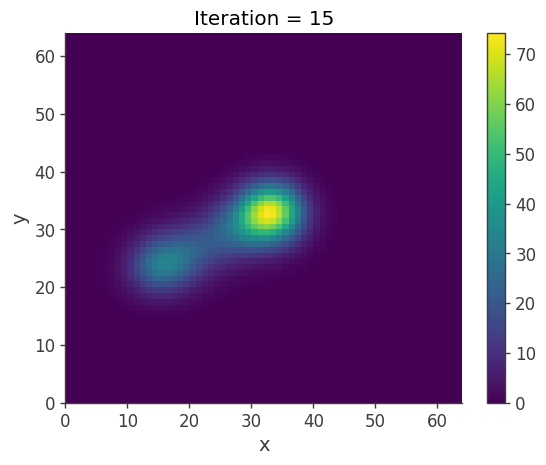

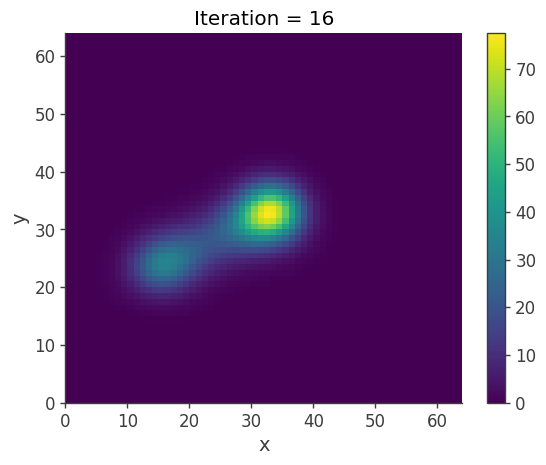

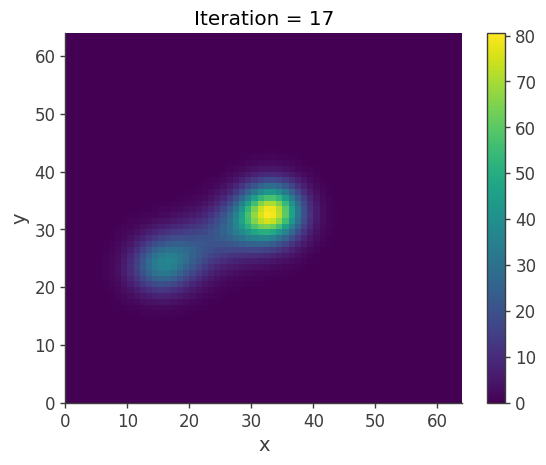

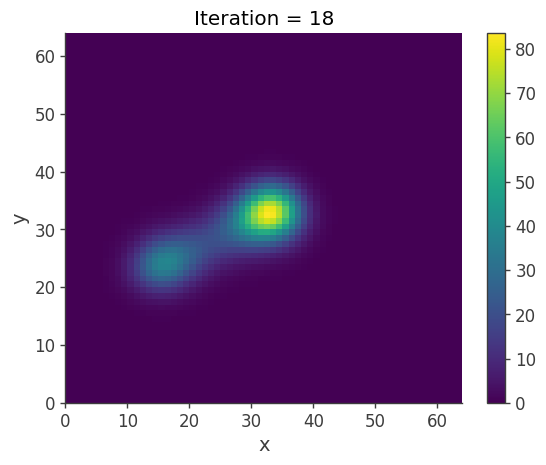

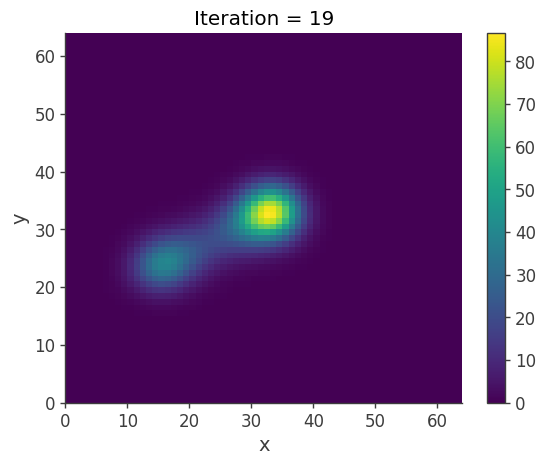

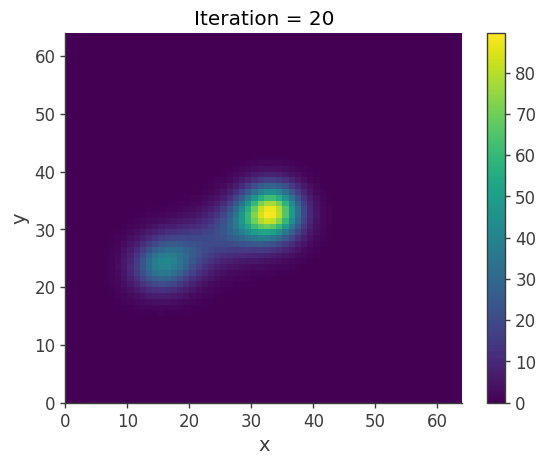

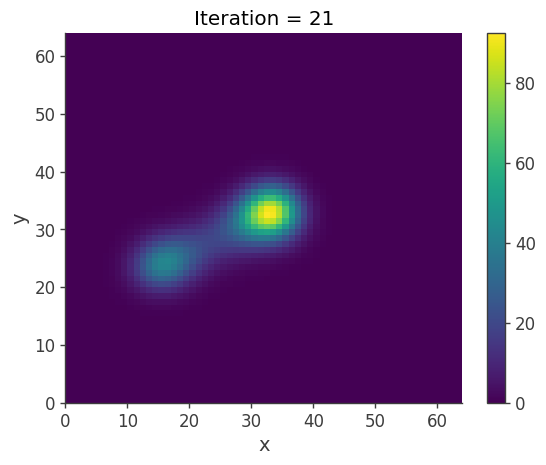

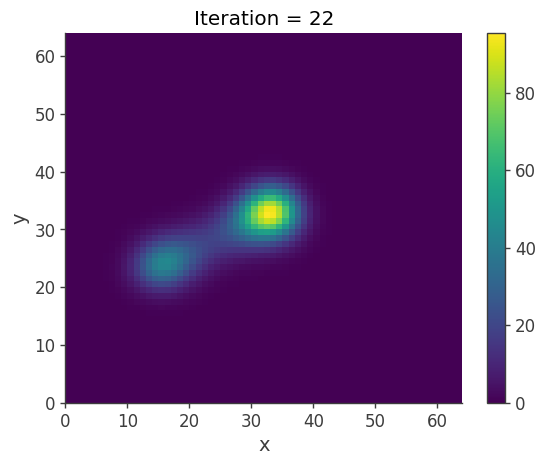

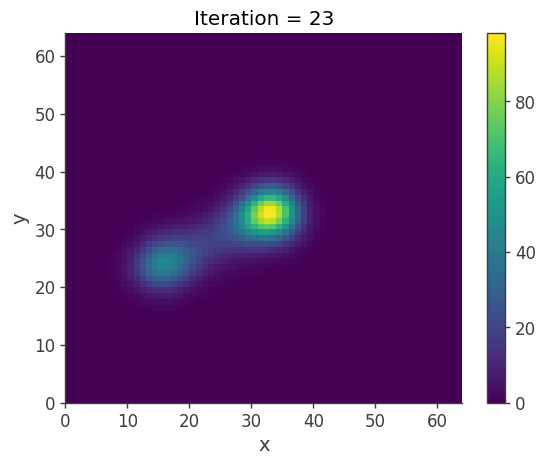

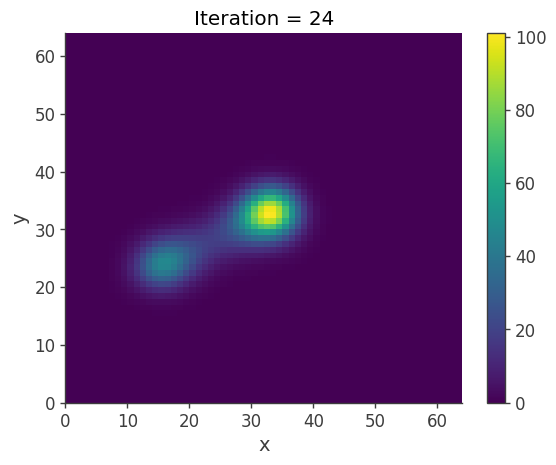

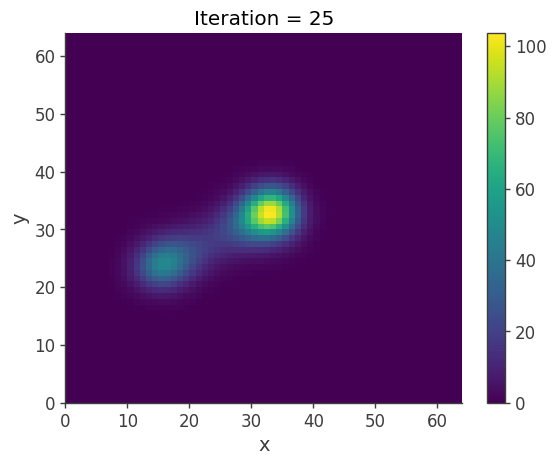

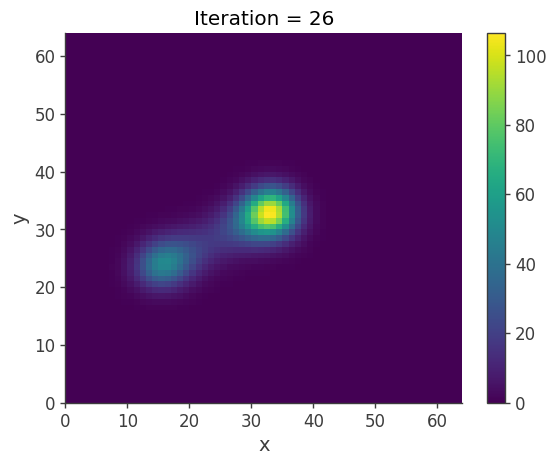

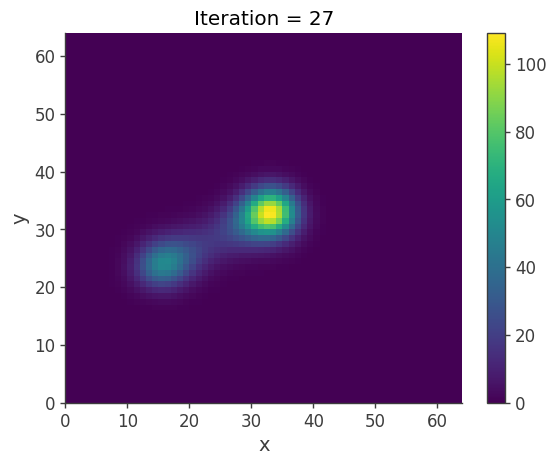

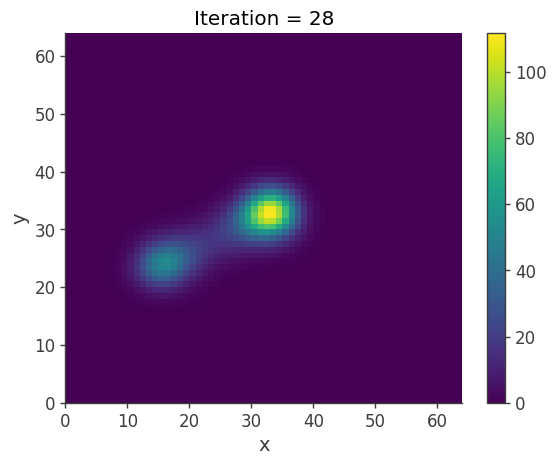

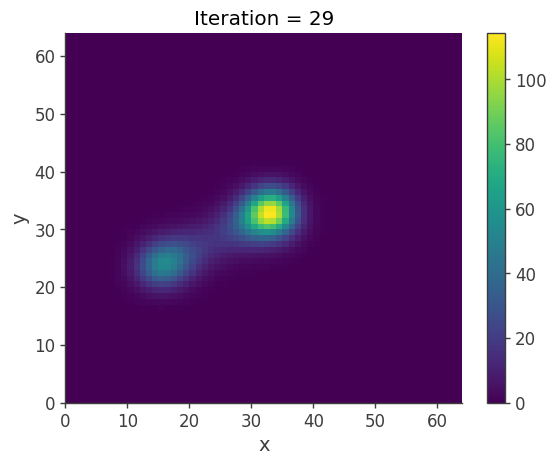

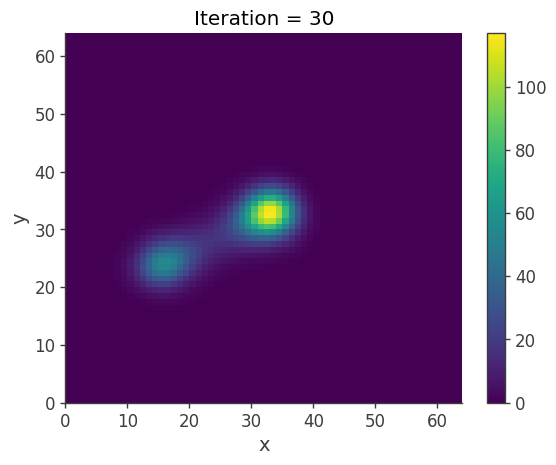

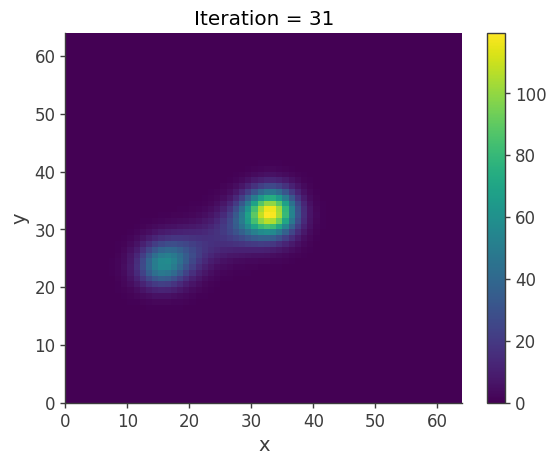

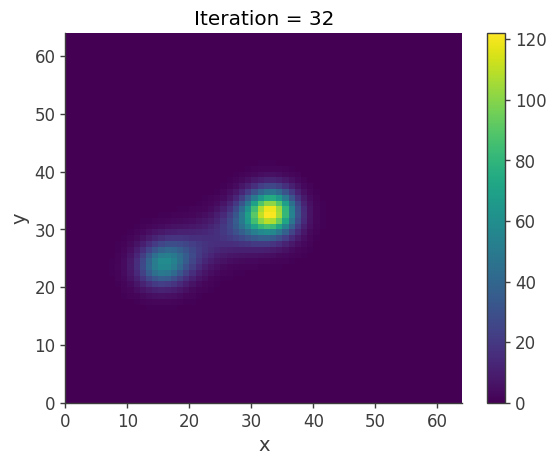

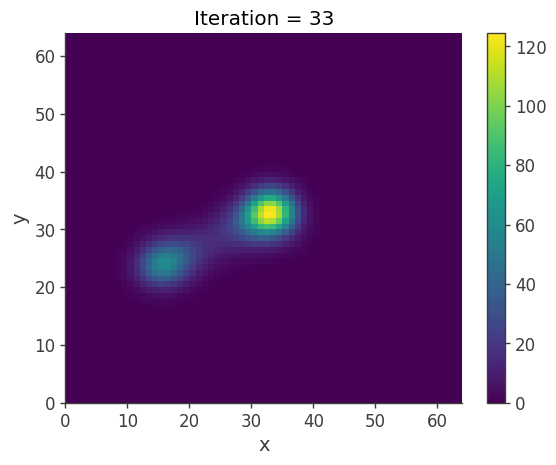

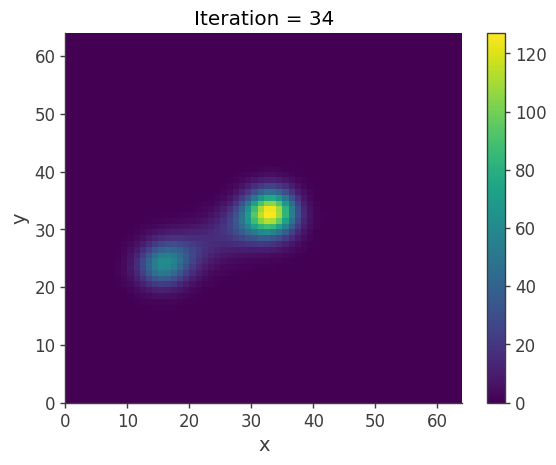

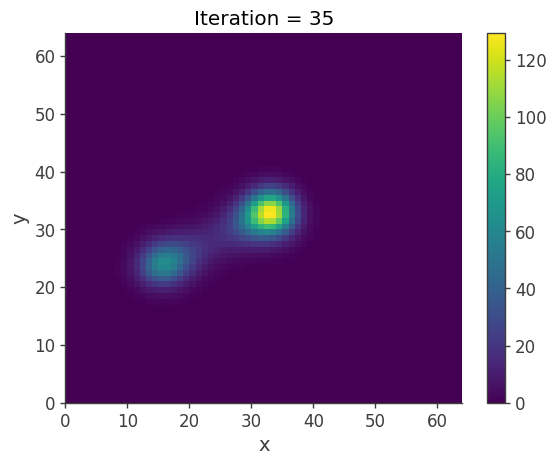

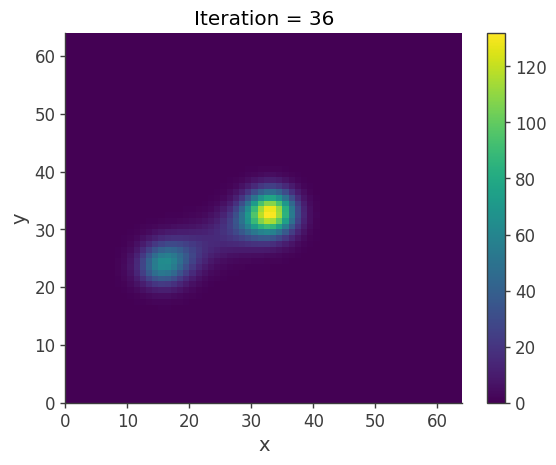

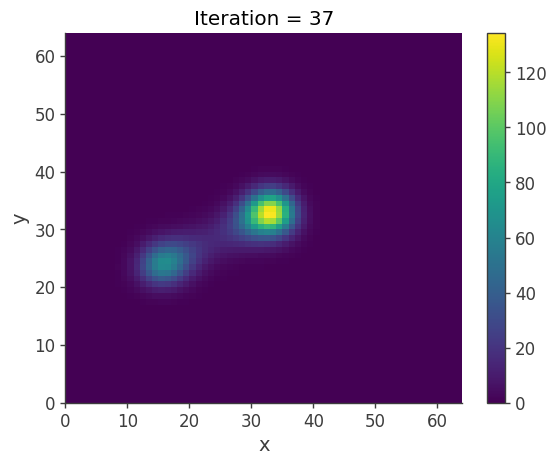

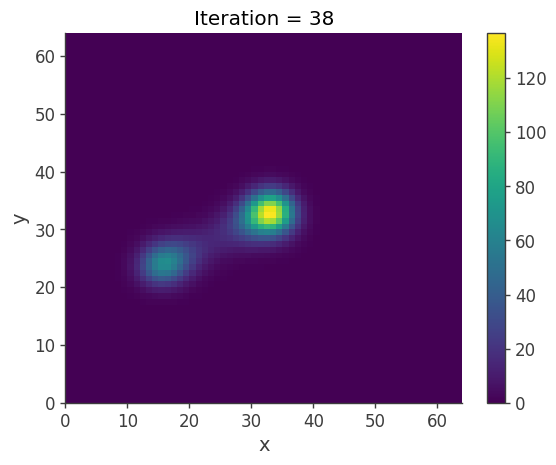

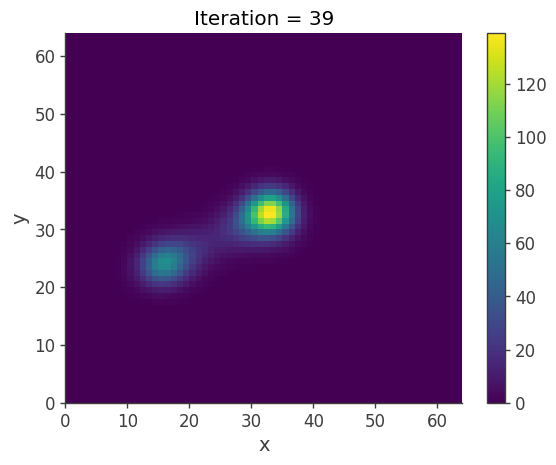

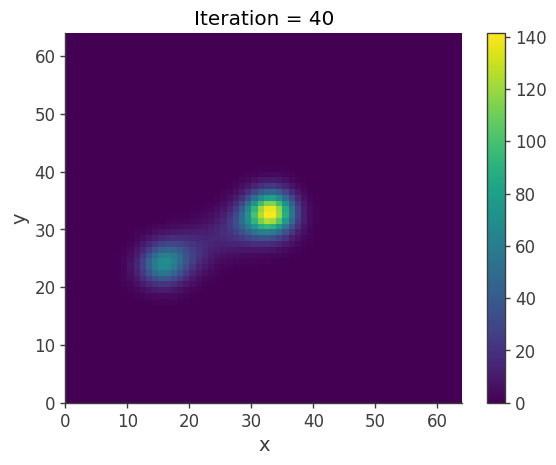

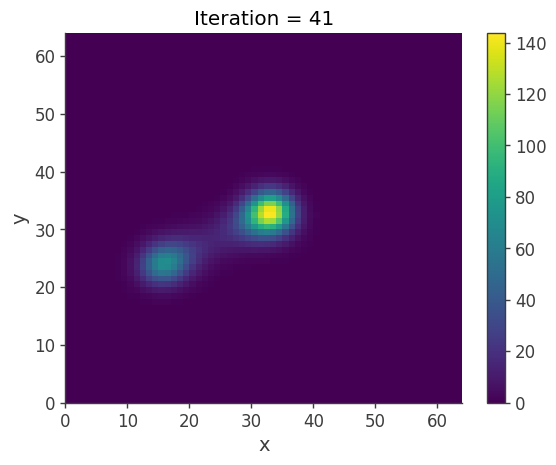

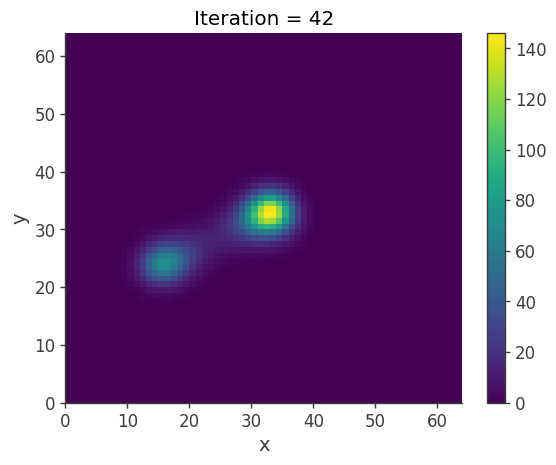

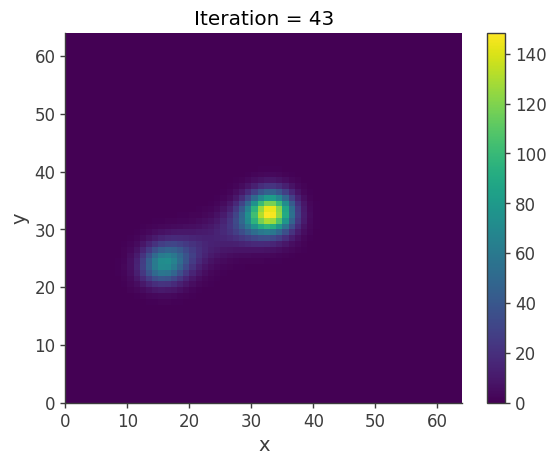

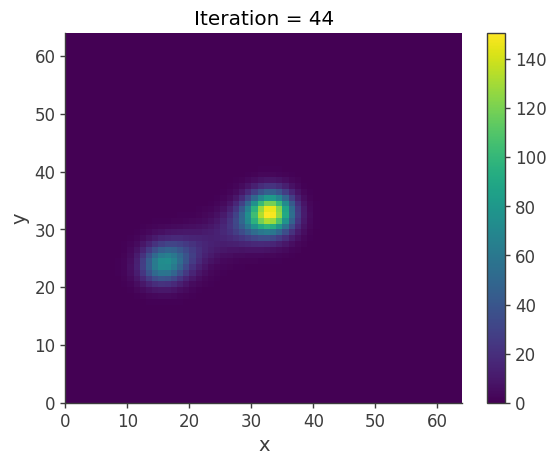

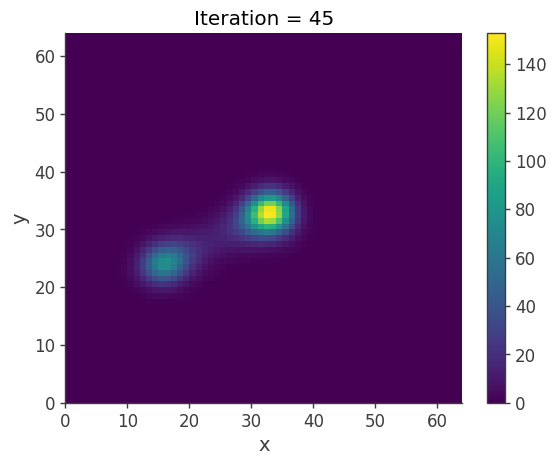

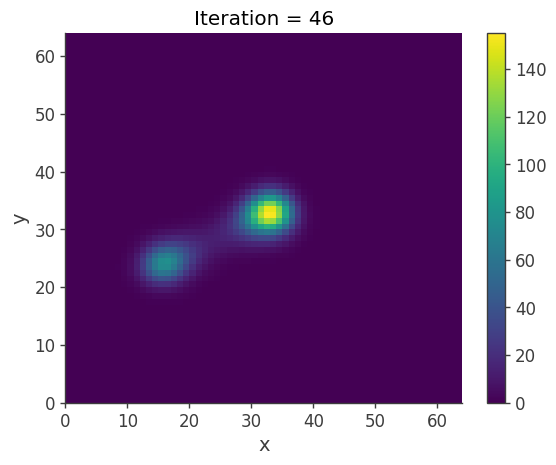

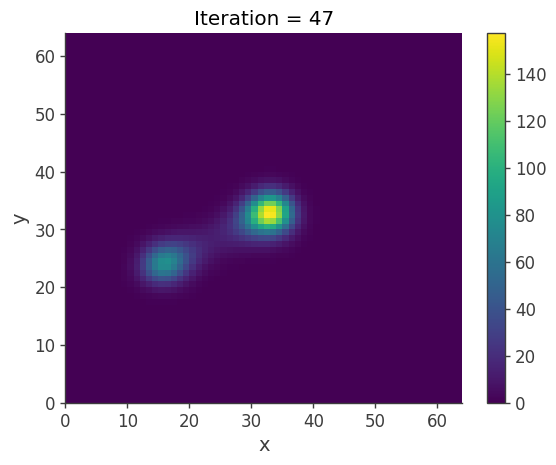

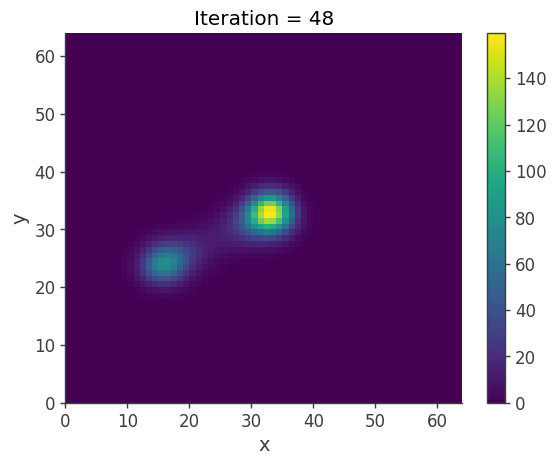

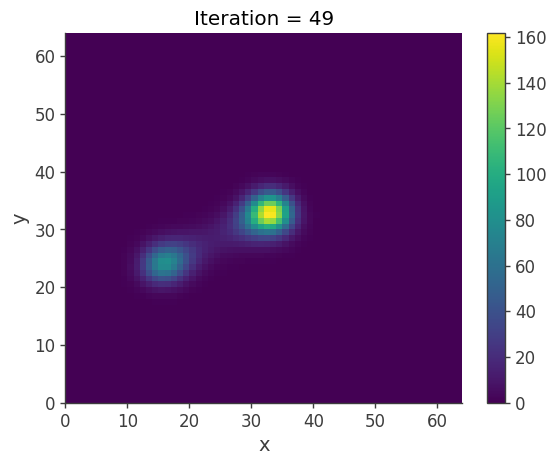

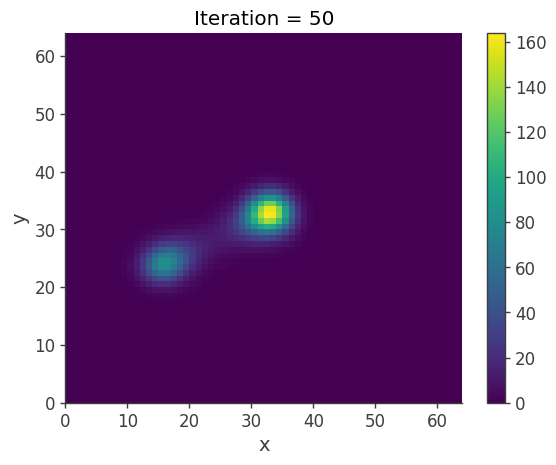

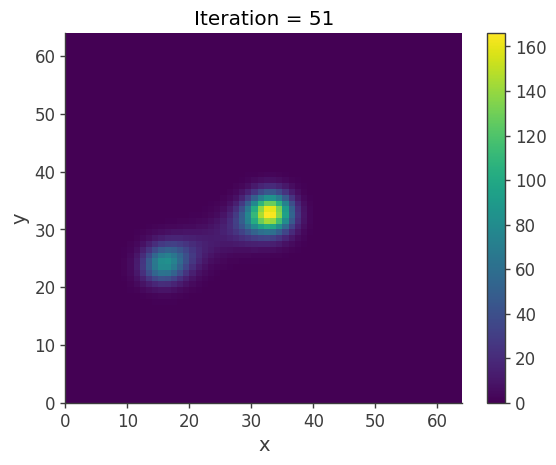

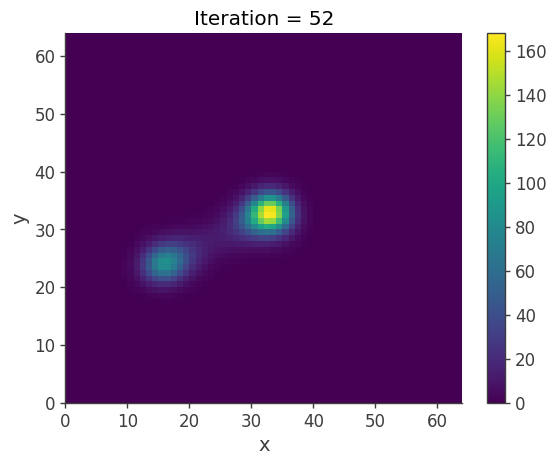

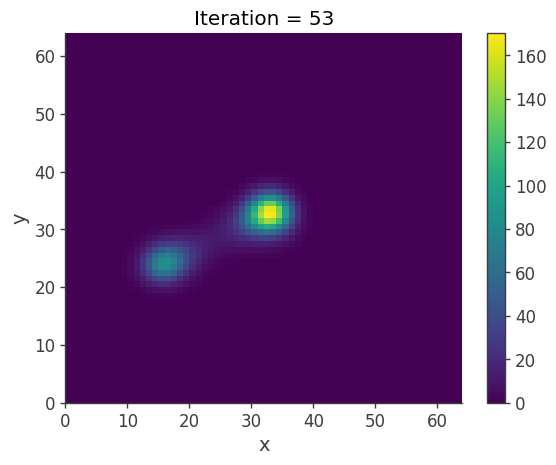

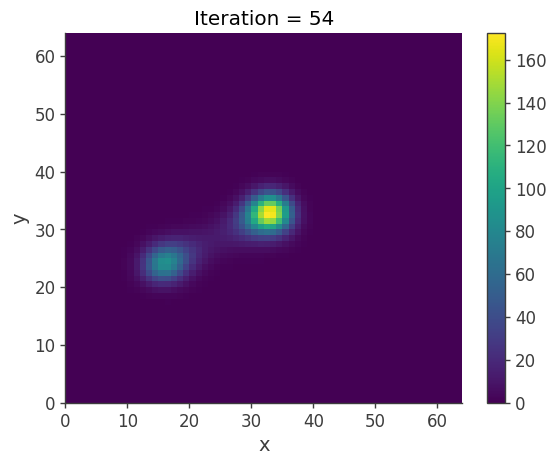

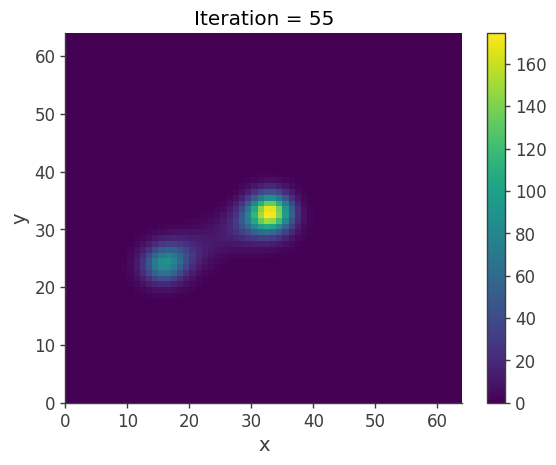

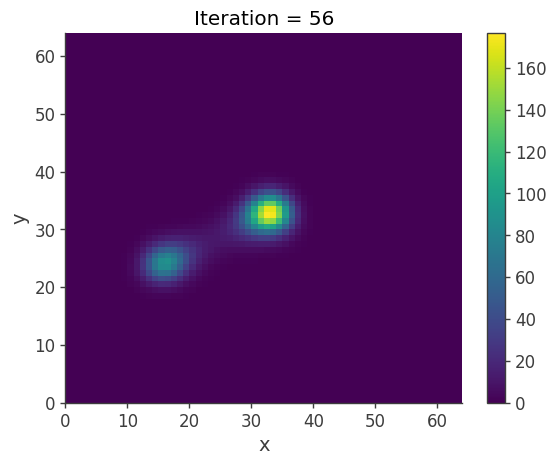

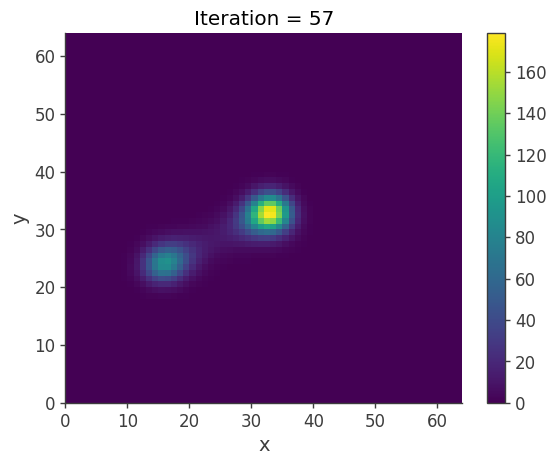

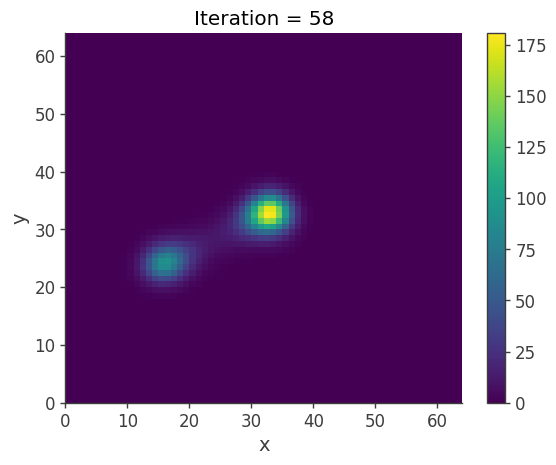

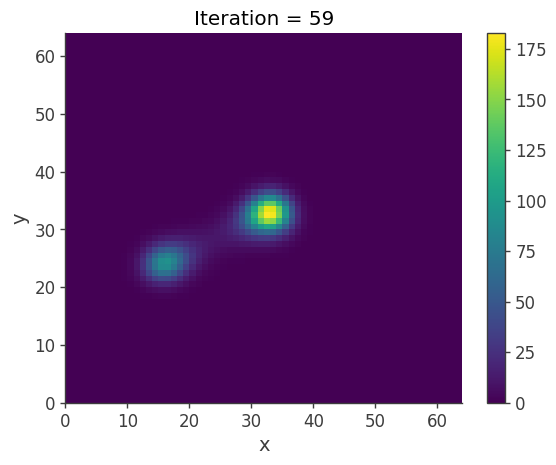

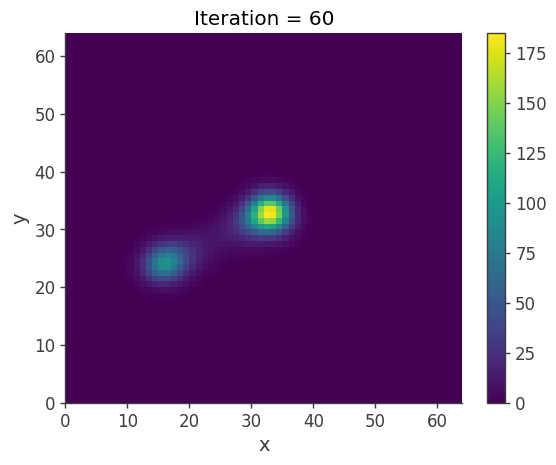

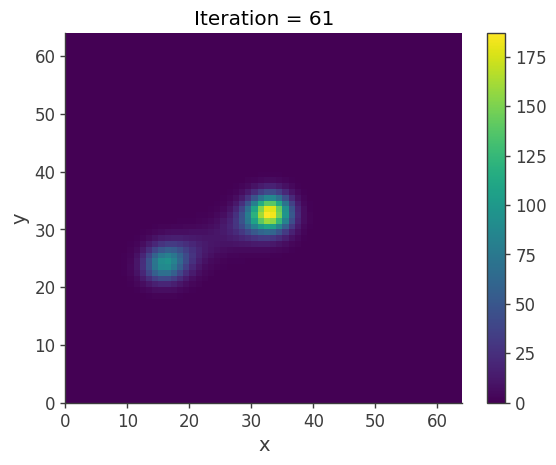

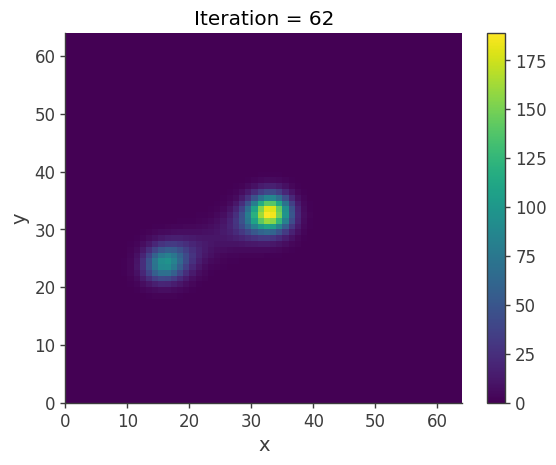

In [37]:
# Visualize results through iterations
for itr in fitsfile[2].data['iteration']:
    image = Histogram.open('results/model.hdf5', f'iteration{itr}')
    ax, _ = image.draw()
    ax.set_title(f'Iteration = {itr}')
    plt.show()